<a href="https://colab.research.google.com/github/shuruq2/ShuruqAlotaibi-NLP-Bayan/blob/main/Bayan_NLP_ShuruqAlotaibi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayan — Bilingual Arabic/English Applied NLP Project
**Shuruq Alotaibi · SDA-AIE-211 · SDAIA Academy**

One notebook, eight sections. Run with **Runtime → Restart session and run all**; every section ends with a `CORE=PASS` marker and writes its evidence to `reports/`.

| Section | Topic | Marker |
|---|---|---|
| 1 | Text processing & tokenisation | `DAY1_NOTEBOOK1_CORE=PASS` |
| 2 | Attention & Transformer architecture | `DAY1_NOTEBOOK2_CORE=PASS` |
| 3 | Topic & sentiment classification | `DAY2_NOTEBOOK3_CORE=PASS` |
| 4 | NER & extractive QA | `DAY2_NOTEBOOK4_CORE=PASS` |
| 5 | Arabic NLP (CAMeL profile) | `DAY3_NOTEBOOK5_CORE=PASS` |
| 6 | Bilingual semantic search + measured extension | `DAY3_NOTEBOOK6_CORE=PASS` |
| 7 | Evaluation & error analysis | `DAY3_NOTEBOOK7_CORE=PASS` |
| 8 | Optimisation & tested service | `DAY4_NOTEBOOK8_CORE=PASS` |

All data is synthetic educational data from the course repository. Results are `MEASURED_SMOKE`.

---
## Section 1 · Text Processing & Tokenisation
**Driving question:** How does Arabic or English text become a model-ready numeric representation without damaging its meaning?

In [1]:
!pip install -q tokenizers transformers pandas matplotlib

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from tokenizers import Tokenizer
from tokenizers.models import BPE

In [3]:
SEED = 42


samples = [
    "مرحباً بكم في برنامج بيان!",
    "معالجة اللغة العربية مهمة.",
    "تعلم الآلة يساعد في تحليل النصوص.",
    "الذكاء الاصطناعي يتطور بسرعة.",
    "معالجة اللغة الطبيعية تربط النصوص بالنماذج."
]

print("Synthetic samples:", len(samples))

Synthetic samples: 5


In [4]:
# Folder for saving results
import os
import json

os.makedirs("reports", exist_ok=True)

def save_report(file_name, data):
    with open("reports/" + file_name, "w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2)
    print("Saved: reports/" + file_name)

In [5]:
import unicodedata
def inspect_unicode(text):
    result = []

    for ch in text:
        char_info = {
            "char": ch,
            "code_point": f"U+{ord(ch):04X}",
            "name": unicodedata.name(ch, "UNKNOWN")
        }

        result.append(char_info)

    return result


unicode_rows = inspect_unicode("أ")

for row in unicode_rows:
    print(row)

{'char': 'أ', 'code_point': 'U+0623', 'name': 'ARABIC LETTER ALEF WITH HAMZA ABOVE'}


In [6]:
ARABIC_DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")
TATWEEL = "\u0640"
WHITESPACE = re.compile(r"\s+")

دالة تنظيف النص

In [7]:
# Clean Arabic text before tokenization
def clean_arabic_text(text):

    # Standardize Unicode characters
    cleaned_text = unicodedata.normalize("NFC", text)

    # Remove Arabic diacritics
    cleaned_text = ARABIC_DIACRITICS.sub("", cleaned_text)

    # Remove Tatweel (ـ)
    cleaned_text = cleaned_text.replace(TATWEEL, "")

    # Remove extra spaces
    cleaned_text = WHITESPACE.sub(" ", cleaned_text)

    return cleaned_text.strip()

I cleaned the Arabic text by removing diacritics, Tatweel, and extra spaces before tokenization.

In [8]:
# Test the cleaning function
example_text = "مَرْحَبــــاً   بكم"

cleaned_text = clean_arabic_text(example_text)

print("Before:", example_text)
print("After: ", cleaned_text)

Before: مَرْحَبــــاً   بكم
After:  مرحبا بكم


In [9]:
# Clean all text samples
cleaned_samples = []

for text in samples:
    cleaned_text = clean_arabic_text(text)
    cleaned_samples.append(cleaned_text)

# Show the results
for text in cleaned_samples:
    print(text)

مرحبا بكم في برنامج بيان!
معالجة اللغة العربية مهمة.
تعلم الآلة يساعد في تحليل النصوص.
الذكاء الاصطناعي يتطور بسرعة.
معالجة اللغة الطبيعية تربط النصوص بالنماذج.


In [10]:
# Create a simple sentence splitter
import re
import unicodedata
import spacy

nlp = spacy.blank("xx")
nlp.add_pipe("sentencizer")

### Sentence Splitting
نقسم النص إلى جمل قبل الترميز.

In [11]:
text = "مرحبا بكم في بيان. هذه جملة ثانية! Is this the third sentence? Yes."

sentences = [s.text for s in nlp(text).sents]
print(sentences)

['مرحبا بكم في بيان.', 'هذه جملة ثانية!', 'Is this the third sentence?', 'Yes.']


In [12]:
# Import the BPE model and trainer
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [13]:
# Special tokens used by the tokenizer
special_tokens = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]",
    "[MASK]"
]

الآن ننشئ BPE Tokenizer

In [14]:
# Create the BPE tokenizer
bpe_tokenizer = Tokenizer(
    BPE(unk_token="[UNK]")
)

ندربه على النصوص


In [15]:
# Configure BPE training
trainer = BpeTrainer(
    vocab_size=100,
    special_tokens=special_tokens
)

bpe_tokenizer.pre_tokenizer = Whitespace()

In [16]:
# Train BPE using the cleaned text
bpe_tokenizer.train_from_iterator(
    cleaned_samples,
    trainer=trainer
)

In [17]:
# Test the trained BPE tokenizer
test_text = "معالجة اللغة العربية مهمة"

encoded = bpe_tokenizer.encode(test_text)

print("Text:", test_text)
print("Tokens:", encoded.tokens)
print("IDs:", encoded.ids)

Text: معالجة اللغة العربية مهمة
Tokens: ['معالجة', 'اللغة', 'العربي', 'ة', 'مهمة']
IDs: [44, 42, 86, 11, 98]


In [18]:
# Count the words in a text
def count_words(text):
    words = text.split()
    return len(words)

نحسب Token Fertility

In [19]:
# Calculate how many tokens are produced per word
def calculate_fertility(tokenizer, text):
    encoded = tokenizer.encode(text)

    number_of_tokens = len(encoded.tokens)
    number_of_words = count_words(text)

    fertility = number_of_tokens / number_of_words

    return fertility

In [20]:
# Calculate fertility for each sample
fertility_results = []

for text in cleaned_samples:
    score = calculate_fertility(bpe_tokenizer, text)
    fertility_results.append(score)

    print(text)
    print("Fertility:", round(score, 2))

    #  average fertility
average_fertility = sum(fertility_results) / len(fertility_results)
print("-------------------------------------------------------------")
print("Average fertility:", round(average_fertility, 2))

مرحبا بكم في برنامج بيان!
Fertility: 1.4
معالجة اللغة العربية مهمة.
Fertility: 1.5
تعلم الآلة يساعد في تحليل النصوص.
Fertility: 1.67
الذكاء الاصطناعي يتطور بسرعة.
Fertility: 2.0
معالجة اللغة الطبيعية تربط النصوص بالنماذج.
Fertility: 1.5
-------------------------------------------------------------
Average fertility: 1.61


نحسب نسبة النصوص التي تنتج أكثر من 10 Tokens.

In [21]:
# Calculate how many texts exceed the token limit
def calculate_truncation_rate(tokenizer, texts, max_length):
    truncated_count = 0

    for text in texts:
        encoded = tokenizer.encode(text)

        if len(encoded.ids) > max_length:
            truncated_count += 1

    rate = truncated_count / len(texts)
    return rate


# Check truncation using a maximum of 10 tokens
max_length = 10

truncation_rate = calculate_truncation_rate(
    bpe_tokenizer,
    cleaned_samples,
    max_length
)

print("Truncation rate:", round(truncation_rate * 100, 2), "%")

Truncation rate: 0.0 %


In [22]:
# Set the same length for all sequences
MAX_LENGTH = 12

bpe_tokenizer.enable_truncation(
    max_length=MAX_LENGTH
)

pad_id = bpe_tokenizer.token_to_id("[PAD]")

bpe_tokenizer.enable_padding(
    length=MAX_LENGTH,
    pad_id=pad_id,
    pad_token="[PAD]"
)

In [23]:
# Test padding and truncation
example = bpe_tokenizer.encode(cleaned_samples[0])

print("Tokens:", example.tokens)
print("IDs:", example.ids)
print("Attention Mask:", example.attention_mask)

Tokens: ['مرحبا', 'بكم', 'في', 'برنام', 'ج', 'بيان', '!', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
IDs: [77, 91, 39, 89, 13, 87, 5, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


In [24]:
import numpy as np
batch = []

for text in cleaned_samples[:2]:
    encoded = bpe_tokenizer.encode(text)
    batch.append(encoded)


# Convert token IDs to arrays
input_ids = []

for item in batch:
    input_ids.append(item.ids)

input_ids = np.array(input_ids)


# Create attention masks
attention_masks = []

for item in batch:
    attention_masks.append(item.attention_mask)

attention_masks = np.array(attention_masks)


print("Input IDs shape:", input_ids.shape)
print("Attention Mask shape:", attention_masks.shape)

Input IDs shape: (2, 12)
Attention Mask shape: (2, 12)


In [25]:
# Create simple random embeddings for demonstration
vocab_size = bpe_tokenizer.get_vocab_size()
embedding_size = 8

embedding_table = np.random.normal(
    0,
    0.02,
    size=(vocab_size, embedding_size)
)

embeddings = embedding_table[input_ids]

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (2, 12, 8)


### BPE and mBERT Comparison
The custom BPE tokenizer is compared with the pretrained multilingual BERT (mBERT) tokenizer on the same Arabic sentence: how each one splits the text, how many tokens it produces and how long it takes.

The BPE tokenizer was trained on the five sentences of this notebook, while mBERT was trained on a much larger multilingual corpus, so the goal is to observe the difference between the two approaches rather than to declare a winner. Note that the BPE count below includes `[PAD]` tokens because padding to 12 was enabled earlier.

In [26]:
# Compare our BPE tokenizer with mBERT
from transformers import AutoTokenizer
import time

comparison_text = "معالجة اللغة الطبيعية مفيدة"

# ----- BPE -----
start_time = time.time()

bpe_result = bpe_tokenizer.encode(comparison_text)
bpe_tokens = bpe_result.tokens

bpe_time = time.time() - start_time


# ----- mBERT -----
mbert_tokenizer = AutoTokenizer.from_pretrained(
    "google-bert/bert-base-multilingual-cased"
)

start_time = time.time()

mbert_tokens = mbert_tokenizer.tokenize(comparison_text)

mbert_time = time.time() - start_time


# ----- Results -----
print("Original Text:")
print(comparison_text)

print("\nBPE Tokens:")
print(bpe_tokens)
print("Number of BPE Tokens:", len(bpe_tokens))
print("BPE Time:", round(bpe_time, 6), "seconds")

print("\nmBERT Tokens:")
print(mbert_tokens)
print("Number of mBERT Tokens:", len(mbert_tokens))
print("mBERT Time:", round(mbert_time, 6), "seconds")

print("\nFinal BPE Metrics:")
print("Average Fertility:", round(average_fertility, 2))
print("Truncation Rate:", round(truncation_rate * 100, 2), "%")

print("\nBPE vs mBERT comparison completed")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Original Text:
معالجة اللغة الطبيعية مفيدة

BPE Tokens:
['معالجة', 'اللغة', 'الطبي', 'عية', 'م', 'في', 'د', 'ة', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Number of BPE Tokens: 12
BPE Time: 0.000393 seconds

mBERT Tokens:
['مع', '##الجة', 'اللغة', 'الطبيعية', 'م', '##فيد', '##ة']
Number of mBERT Tokens: 7
mBERT Time: 0.000529 seconds

Final BPE Metrics:
Average Fertility: 1.61
Truncation Rate: 0.0 %

BPE vs mBERT comparison completed


In [27]:
# Check section 1 results
assert clean_arabic_text("مَرْحَبــــاً") == "مرحبا"
assert average_fertility > 0
assert 0 <= truncation_rate <= 1

save_report("01_tokenization.json", {
    "average_fertility": round(average_fertility, 2),
    "truncation_rate": truncation_rate,
    "bpe_tokens": bpe_tokens,
    "mbert_tokens": mbert_tokens
})

print("DAY1_NOTEBOOK1_CORE=PASS")

Saved: reports/01_tokenization.json
DAY1_NOTEBOOK1_CORE=PASS


---
## Section 2 · Attention & Transformer Architecture

### Preparing the Environment
First, we prepare the required libraries and use a fixed random seed. This keeps the numerical experiments consistent when the notebook is executed again.

In [28]:
import importlib.metadata
import subprocess
import sys
import math
import numpy as np

required_packages = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2"
}

packages_to_install = []

for package, version in required_packages.items():
    try:
        installed_version = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        installed_version = None

    if installed_version != version:
        packages_to_install.append(f"{package}=={version}")

if packages_to_install:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        *packages_to_install
    ])

SEED = 42
random_generator = np.random.default_rng(SEED)

print("NumPy version:", np.__version__)
print("Environment ready")

NumPy version: 2.1.3
Environment ready


2. Creating the Attention Mechanism
Attention uses three main components: Query, Key, and Value. Query and Key are compared to calculate similarity scores. Softmax converts these scores into attention weights, which are then used to combine the Value vectors.

In [29]:
def apply_softmax(values, axis=-1):
    shifted_values = values - np.max(
        values,
        axis=axis,
        keepdims=True
    )

    exp_values = np.exp(shifted_values)

    return exp_values / np.sum(
        exp_values,
        axis=axis,
        keepdims=True
    )


def attention_operation(query, key, value, allowed_mask=None):

    if query.shape[-1] != key.shape[-1]:
        raise ValueError("Query and Key dimensions must match")

    if key.shape[-2] != value.shape[-2]:
        raise ValueError("Key and Value sequence lengths must match")

    key_dimension = query.shape[-1]

    similarity_scores = (
        query @ np.swapaxes(key, -1, -2)
    ) / math.sqrt(key_dimension)

    if allowed_mask is not None:

        mask = np.asarray(
            allowed_mask,
            dtype=bool
        )

        mask = np.broadcast_to(
            mask,
            similarity_scores.shape
        )

        if np.any(mask.sum(axis=-1) == 0):
            raise ValueError(
                "Each query must access at least one key"
            )

        similarity_scores = np.where(
            mask,
            similarity_scores,
            -np.inf
        )

    attention_weights = apply_softmax(
        similarity_scores,
        axis=-1
    )

    context_output = attention_weights @ value

    return context_output, attention_weights, similarity_scores


query = np.array([
    [1.0, 0.0],
    [0.0, 1.0]
])

key = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])

value = np.array([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0]
])


attention_output, attention_weights, attention_scores = attention_operation(
    query,
    key,
    value
)


print("Scores shape:", attention_scores.shape)

print(
    "Attention weights:\n",
    np.round(attention_weights, 3)
)

print(
    "Weight sums:",
    attention_weights.sum(axis=-1)
)

print(
    "Output:\n",
    np.round(attention_output, 3)
)


assert attention_output.shape == (2, 2)

assert np.allclose(
    attention_weights.sum(axis=-1),
    1.0
)

print("Attention calculation = PASS")

Scores shape: (2, 3)
Attention weights:
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]]
Weight sums: [1. 1.]
Output:
 [[6.017 3.983]
 [3.983 6.017]]
Attention calculation = PASS


3. Examining the Effect of Scaling
Attention scores can become large when the vector dimension increases. Dividing the scores by the square root of the key dimension helps Softmax produce a more stable distribution.

Entropy without scaling: 0.379
Entropy with scaling: 1.624


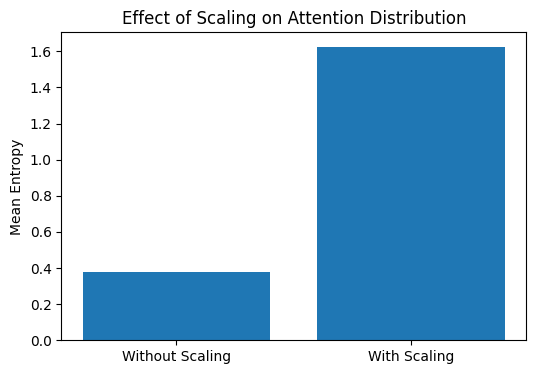

In [30]:
import matplotlib.pyplot as plt


def distribution_entropy(probabilities):

    safe_values = np.clip(
        probabilities,
        1e-12,
        1.0
    )

    entropy_values = -np.sum(
        safe_values * np.log(safe_values),
        axis=-1
    )

    return float(
        entropy_values.mean()
    )


large_query = random_generator.normal(
    size=(6, 64)
)

large_key = random_generator.normal(
    size=(6, 64)
)


original_scores = large_query @ large_key.T


weights_without_scaling = apply_softmax(
    original_scores
)


weights_with_scaling = apply_softmax(
    original_scores / math.sqrt(large_query.shape[-1])
)


entropy_without = distribution_entropy(
    weights_without_scaling
)

entropy_with = distribution_entropy(
    weights_with_scaling
)


print(
    "Entropy without scaling:",
    round(entropy_without, 3)
)

print(
    "Entropy with scaling:",
    round(entropy_with, 3)
)


plt.figure(figsize=(6, 4))

plt.bar(
    ["Without Scaling", "With Scaling"],
    [entropy_without, entropy_with]
)

plt.ylabel("Mean Entropy")
plt.title("Effect of Scaling on Attention Distribution")

plt.show()

Restricting Attention with a Mask
A mask controls which positions are available during attention. In this example, a causal-style mask is used so some future positions are blocked before Softmax is applied.

In [31]:
attention_mask = np.tril(
    np.ones(
        (2, 3),
        dtype=bool
    )
)


masked_output, masked_attention, masked_scores = attention_operation(
    query,
    key,
    value,
    allowed_mask=attention_mask
)


print(
    "Attention Mask:\n",
    attention_mask.astype(int)
)

print(
    "\nWeights after masking:\n",
    np.round(masked_attention, 3)
)


assert masked_attention[0, 1] == 0.0
assert masked_attention[0, 2] == 0.0


print("Attention masking = PASS")

Attention Mask:
 [[1 0 0]
 [1 1 0]]

Weights after masking:
 [[1.   0.   0.  ]
 [0.33 0.67 0.  ]]
Attention masking = PASS


Visualizing the Mask Effect
To make the effect of masking easier to see, the attention weights are displayed as a simple matrix visualization. Blocked positions should receive zero attention.

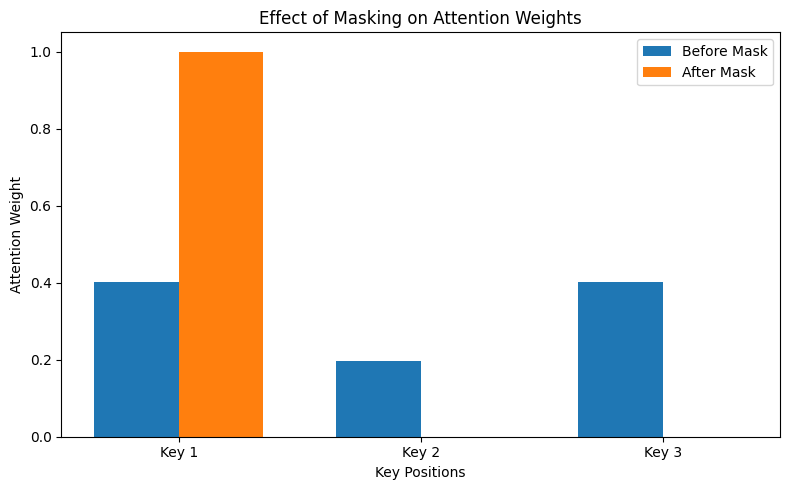

In [32]:
# Compare attention weights before and after masking

key_positions = [
    f"Key {i + 1}"
    for i in range(attention_weights.shape[1])
]

before_mask = attention_weights[0]
after_mask = masked_attention[0]

x = np.arange(len(key_positions))
bar_width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - bar_width / 2,
    before_mask,
    bar_width,
    label="Before Mask"
)

plt.bar(
    x + bar_width / 2,
    after_mask,
    bar_width,
    label="After Mask"
)

plt.xticks(
    x,
    key_positions
)

plt.xlabel("Key Positions")
plt.ylabel("Attention Weight")

plt.title(
    "Effect of Masking on Attention Weights"
)

plt.legend()
plt.tight_layout()
plt.show()

Splitting Representations into Multiple Heads
Multi-head attention allows the representation to be divided into several smaller heads. Each head works with a smaller feature dimension, and the heads are combined again afterward.

In [33]:
def divide_into_heads(data, head_count):

    batch_size, token_count, model_size = data.shape

    if model_size % head_count != 0:
        raise ValueError(
            "Model size must be divisible by the number of heads"
        )

    size_per_head = model_size // head_count

    reshaped_data = data.reshape(
        batch_size,
        token_count,
        head_count,
        size_per_head
    )

    return reshaped_data.transpose(
        0,
        2,
        1,
        3
    )


def join_attention_heads(data):

    batch_size, head_count, token_count, head_size = data.shape

    reordered_data = data.transpose(
        0,
        2,
        1,
        3
    )

    return reordered_data.reshape(
        batch_size,
        token_count,
        head_count * head_size
    )


sample_data = random_generator.normal(
    size=(2, 5, 12)
)


separated_heads = divide_into_heads(
    sample_data,
    head_count=3
)


restored_data = join_attention_heads(
    separated_heads
)


print(
    "Original shape:",
    sample_data.shape
)

print(
    "After splitting:",
    separated_heads.shape
)

print(
    "After combining:",
    restored_data.shape
)


assert separated_heads.shape == (2, 3, 5, 4)

assert np.allclose(
    restored_data,
    sample_data
)


print("Multi-head transformation = PASS")

Original shape: (2, 5, 12)
After splitting: (2, 3, 5, 4)
After combining: (2, 5, 12)
Multi-head transformation = PASS


Understanding the Shape Change
The model dimension is divided between the attention heads. In this example, a model dimension of 12 is divided across three heads, giving four features to each head.

A Transformer encoder combines self-attention with feed-forward processing, residual connections, and normalization. Here, a PyTorch encoder layer is used to confirm that the sequence keeps the expected output dimensions.

In [34]:
try:

    import torch

    torch.manual_seed(SEED)


    transformer_layer = torch.nn.TransformerEncoderLayer(
        d_model=12,
        nhead=3,
        dim_feedforward=24,
        dropout=0.0,
        batch_first=True,
        norm_first=False
    )


    transformer_layer.eval()


    encoder_input = torch.tensor(
        sample_data,
        dtype=torch.float32
    )


    with torch.no_grad():

        transformed_output = transformer_layer(
            encoder_input
        )


    print(
        "Input shape:",
        tuple(encoder_input.shape)
    )

    print(
        "Encoder output shape:",
        tuple(transformed_output.shape)
    )


    assert tuple(
        transformed_output.shape
    ) == (2, 5, 12)


    print("Transformer encoder = PASS")


except ModuleNotFoundError:

    print(
        "PyTorch is unavailable. NumPy attention is still complete."
    )

Input shape: (2, 5, 12)
Encoder output shape: (2, 5, 12)
Transformer encoder = PASS


Comparing the Custom Attention with PyTorch
The NumPy implementation is compared with PyTorch's official scaled dot-product attention function. If both implementations produce almost identical outputs, it provides a useful check that the manual calculation is correct.

In [35]:
try:

    import torch
    import torch.nn.functional as F


    torch_query = torch.tensor(
        query,
        dtype=torch.float64
    )[None, None, :, :]


    torch_key = torch.tensor(
        key,
        dtype=torch.float64
    )[None, None, :, :]


    torch_value = torch.tensor(
        value,
        dtype=torch.float64
    )[None, None, :, :]


    official_output = F.scaled_dot_product_attention(
        torch_query,
        torch_key,
        torch_value,
        dropout_p=0.0
    )


    custom_output = attention_output[
        None,
        None,
        :,
        :
    ]


    largest_difference = float(
        np.max(
            np.abs(
                official_output.numpy()
                - custom_output
            )
        )
    )


    print(
        "Largest difference:",
        f"{largest_difference:.3e}"
    )


    assert largest_difference < 1e-9


    print(
        "Custom/PyTorch comparison = PASS"
    )


except ModuleNotFoundError:

    print(
        "PyTorch comparison was skipped."
    )

Largest difference: 4.441e-16
Custom/PyTorch comparison = PASS


Comparing Two BERT Configurations
BERT models can have different vocabulary sizes and parameter distributions. Here, two BERT checkpoints are inspected to compare their total parameter counts and the proportion used by the embedding component.

In [36]:
from transformers import AutoConfig


bert_models = [
    "google-bert/bert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da"
]


expected_parameter_counts = {
    "google-bert/bert-base-multilingual-cased": 177_853_440,
    "CAMeL-Lab/bert-base-arabic-camelbert-da": 109_081_344
}


def inspect_bert_parameters(model_name):

    model_config = AutoConfig.from_pretrained(
        model_name
    )


    assert model_config.model_type == "bert"


    hidden_size = model_config.hidden_size

    intermediate_size = model_config.intermediate_size


    embedding_count = (
        model_config.vocab_size * hidden_size
        + model_config.max_position_embeddings * hidden_size
        + model_config.type_vocab_size * hidden_size
        + 2 * hidden_size
    )


    layer_count = (
        3 * (
            hidden_size * hidden_size
            + hidden_size
        )

        + (
            hidden_size * hidden_size
            + hidden_size
        )

        + 2 * hidden_size

        + (
            hidden_size * intermediate_size
            + intermediate_size
        )

        + (
            intermediate_size * hidden_size
            + hidden_size
        )

        + 2 * hidden_size
    )


    pooler_count = (
        hidden_size * hidden_size
        + hidden_size
    )


    total_count = (
        embedding_count
        + model_config.num_hidden_layers * layer_count
        + pooler_count
    )


    return {

        "model":
            model_name,

        "vocabulary":
            model_config.vocab_size,

        "parameters":
            total_count,

        "embedding_percentage":
            embedding_count / total_count
    }


bert_results = []


for model_name in bert_models:

    model_result = inspect_bert_parameters(
        model_name
    )

    bert_results.append(
        model_result
    )


    print("\nModel:", model_result["model"])

    print(
        "Vocabulary:",
        f'{model_result["vocabulary"]:,}'
    )

    print(
        "Parameters:",
        f'{model_result["parameters"]:,}'
    )

    print(
        "Embedding share:",
        f'{model_result["embedding_percentage"]:.1%}'
    )


assert all(

    result["parameters"]
    == expected_parameter_counts[result["model"]]

    for result in bert_results
)


print(
    "\nBERT parameter comparison = PASS"
)


Model: google-bert/bert-base-multilingual-cased
Vocabulary: 119,547
Parameters: 177,853,440
Embedding share: 51.8%


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]


Model: CAMeL-Lab/bert-base-arabic-camelbert-da
Vocabulary: 30,000
Parameters: 109,081,344
Embedding share: 21.5%

BERT parameter comparison = PASS



Visual Comparison of the BERT Models
A chart is used to make the parameter difference between the two BERT configurations easier to observe.

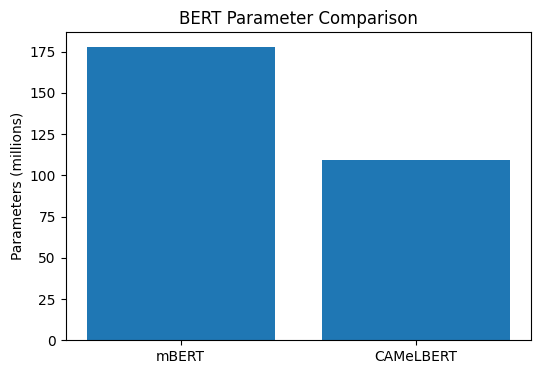

In [37]:
names = ["mBERT", "CAMeLBERT"]
parameters = [result["parameters"] / 1_000_000 for result in bert_results]

plt.figure(figsize=(6, 4))
plt.bar(names, parameters)
plt.ylabel("Parameters (millions)")
plt.title("BERT Parameter Comparison")
plt.show()

Running a Real Transformer Model
Next, a pretrained multilingual Transformer processes one Arabic and one English sentence. We inspect its hidden states and attention tensors to see the shapes produced during a real forward pass.

In [38]:
import torch

from transformers import AutoModel
from transformers import AutoTokenizer
from transformers.utils import logging as hf_logging


hf_logging.set_verbosity_error()


transformer_name = (
    "distilbert/distilbert-base-multilingual-cased"
)


transformer_tokenizer = AutoTokenizer.from_pretrained(
    transformer_name,
    use_fast=True
)


transformer_model = AutoModel.from_pretrained(
    transformer_name,
    attn_implementation="eager"
)


transformer_model.eval()


example_sentences = [
    "الخدمة لم تتأخر.",
    "The service was not delayed."
]


tokenized_input = transformer_tokenizer(
    example_sentences,
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt"
)


with torch.no_grad():

    transformer_result = transformer_model(
        **tokenized_input,
        output_attentions=True
    )


model_parameter_count = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
)


first_attention_shape = tuple(
    transformer_result.attentions[0].shape
)


last_hidden_shape = tuple(
    transformer_result.last_hidden_state.shape
)


arabic_token_list = transformer_tokenizer.convert_ids_to_tokens(
    tokenized_input["input_ids"][0]
)


arabic_length = int(
    tokenized_input["attention_mask"][0].sum()
)


selected_attention = (
    transformer_result.attentions[0][
        0,
        0,
        :arabic_length,
        :arabic_length
    ]
    .cpu()
    .numpy()
)


print(
    "Model:",
    transformer_name
)

print(
    "Parameters:",
    f"{model_parameter_count:,}"
)

print(
    "Hidden states:",
    last_hidden_shape
)

print(
    "Attention tensor:",
    first_attention_shape
)

print(
    "Arabic tokens:",
    arabic_token_list[:arabic_length]
)

print(
    "Attention row sums:",
    selected_attention.sum(axis=-1)
)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Parameters: 134,734,080
Hidden states: (2, 10, 768)
Attention tensor: (2, 12, 10, 10)
Arabic tokens: ['[CLS]', 'ال', '##خدمة', 'لم', 'ت', '##ت', '##أ', '##خر', '.', '[SEP]']
Attention row sums: [1.         1.         0.9999998  1.         1.         1.
 1.         0.99999994 1.         0.9999999 ]


Visualizing Token Relationships

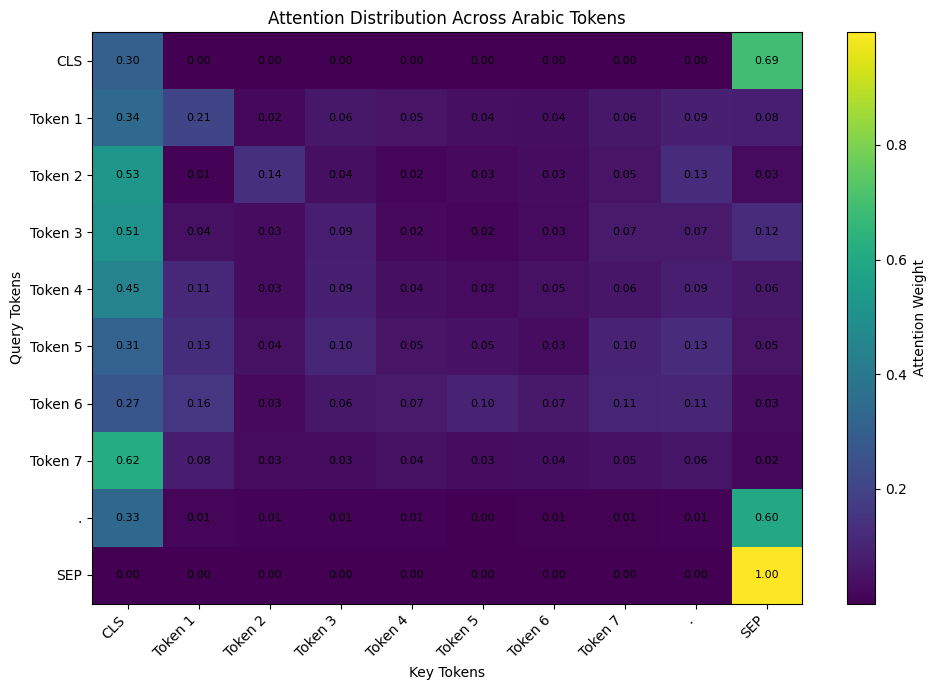

In [39]:
# Create clear labels for the attention visualization
display_labels = [
    "CLS",
    "Token 1",
    "Token 2",
    "Token 3",
    "Token 4",
    "Token 5",
    "Token 6",
    "Token 7",
    ".",
    "SEP"
]

# Keep only the labels needed for the current sequence
display_labels = display_labels[:arabic_length]


# Create the attention matrix
figure, axis = plt.subplots(
    figsize=(10, 7)
)

attention_image = axis.imshow(
    selected_attention,
    aspect="auto"
)


# Display attention values inside the cells
for row in range(arabic_length):
    for column in range(arabic_length):

        axis.text(
            column,
            row,
            f"{selected_attention[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )


# Add readable token labels
axis.set_xticks(range(arabic_length))
axis.set_xticklabels(
    display_labels,
    rotation=45,
    ha="right"
)

axis.set_yticks(range(arabic_length))
axis.set_yticklabels(display_labels)


axis.set_xlabel("Key Tokens")
axis.set_ylabel("Query Tokens")

axis.set_title(
    "Attention Distribution Across Arabic Tokens"
)


figure.colorbar(
    attention_image,
    ax=axis,
    label="Attention Weight"
)

figure.tight_layout()

plt.show()

Checking the Real Model Output

In [40]:
assert model_parameter_count > 100_000_000


assert last_hidden_shape[:2] == tuple(
    tokenized_input["input_ids"].shape
)


assert first_attention_shape[0] == 2


assert (
    first_attention_shape[2]
    == first_attention_shape[3]
)


assert np.allclose(
    selected_attention.sum(axis=-1),
    1.0,
    atol=1e-5
)


print(
    "Real Transformer forward pass = PASS"
)

Real Transformer forward pass = PASS


### What Can Attention Tell Us?

**Encoder flow:** tokens → embeddings + positions → in each layer: self-attention `softmax(QKᵀ/√d)·V` → residual + LayerNorm → feed-forward → final contextual vectors → task head.

**Limits:** a high attention weight only shows that a token was *mixed in* by one head in one layer. It does not prove that this token *caused* the prediction, because:
- the model has many heads and layers,
- the values are transformed again after attention,
- special tokens like `[CLS]` and `[SEP]` often get high weights without meaning.

So I use the attention map only to check shapes and masks, not to explain the model's decision.

الانتباه يوضح كيف تُخلط المعلومات، لكنه ليس تفسيرًا لسبب قرار النموذج.

Final Notebook Validation

In [41]:
notebook_checks = {

    "attention_weights":
        np.allclose(
            attention_weights.sum(axis=-1),
            1.0
        ),

    "bert_models":
        len(bert_results) == 2
        and all(
            result["parameters"]
            == expected_parameter_counts[result["model"]]

            for result in bert_results
        ),

    "real_transformer":
        model_parameter_count > 100_000_000
        and len(transformer_result.attentions) > 0,

    "attention_shape":
        attention_output.shape == (2, 2),

    "mask_check":
        masked_attention[0, 1] == 0
        and masked_attention[0, 2] == 0,

    "multi_head_restore":
        np.allclose(
            restored_data,
            sample_data
        )
}


for check_name, check_result in notebook_checks.items():

    if check_result:
        status = "PASS"

    else:
        status = "FAIL"

    print(
        check_name,
        ":",
        status
    )


assert all(
    notebook_checks.values()
)

save_report("02_attention.json", {
    "entropy_without_scaling": round(entropy_without, 3),
    "entropy_with_scaling": round(entropy_with, 3),
    "pytorch_difference": largest_difference
})

print("DAY1_NOTEBOOK2_CORE=PASS")

attention_weights : PASS
bert_models : PASS
real_transformer : PASS
attention_shape : PASS
mask_check : PASS
multi_head_restore : PASS
Saved: reports/02_attention.json
DAY1_NOTEBOOK2_CORE=PASS


My Design Decision
For an encoder-based NLP task, a padding mask is useful because padded positions should not contribute to the attention calculation. The Query, Key, and Value tensors contain representations for the tokens in the input sequence. Their sequence dimensions must remain compatible for the attention calculation. If the mask meaning is accidentally reversed, valid tokens could be blocked while padded positions remain available, producing incorrect attention behaviour.

---
## Section 3 · Topic & Sentiment Classification

### Importing the Required Libraries
The required libraries are imported for text processing, classification, evaluation, and Transformer training.

In [42]:
import csv
import io
import json
import math
import os


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer
)



In [43]:
import urllib.request
import urllib.request
from collections import Counter

DATA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_classification.csv"

try:
    with urllib.request.urlopen(DATA_URL, timeout=20) as response:
        content = response.read().decode("utf-8")

    rows = list(
        csv.DictReader(io.StringIO(content))
    )

    data_source = "course_dataset"

except Exception:
    raise RuntimeError("The dataset could not be loaded.")


print("Number of examples:", len(rows))

print(
    "Topics:",
    Counter(row["topic"] for row in rows)
)

print(
    "Languages:",
    Counter(row["language"] for row in rows)
)

Number of examples: 40
Topics: Counter({'digital_service': 10, 'permit': 10, 'health': 10, 'transport': 10})
Languages: Counter({'ar': 20, 'en': 20})


In [44]:
print("Dataset columns:", rows[0].keys())
print("First row:", rows[0])

Dataset columns: dict_keys(['example_id', 'group_id', 'split', 'language', 'text', 'topic', 'sentiment'])
First row: {'example_id': 'D-001', 'group_id': 'DG-01', 'split': 'train', 'language': 'ar', 'text': 'تعذر تسجيل الدخول إلى البوابة', 'topic': 'digital_service', 'sentiment': 'negative'}


In [45]:
train_data = [row for row in rows if row["split"] == "train"]
validation_data = [row for row in rows if row["split"] == "validation"]
test_data = [row for row in rows if row["split"] == "test"]

print(
    len(train_data),
    len(validation_data),
    len(test_data)
)

24 8 8


In [46]:
# Make sure the same group_id is not in two different splits
group_splits = {}

for row in rows:
    group = row["group_id"]
    group_splits.setdefault(group, set()).add(row["split"])

for group, splits in group_splits.items():
    assert len(splits) == 1, group

print("No group appears in more than one split")

No group appears in more than one split


# Sentiment Classification — Baseline
Train a baseline sentiment classifier using the same grouped train, validation, and test splits.

In [47]:
sentiment_model = make_pipeline(
    TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5)
    ),
    LinearSVC(random_state=SEED)
)

sentiment_model.fit(
    [row["text"] for row in train_data],
    [row["sentiment"] for row in train_data]
)

sentiment_val_pred = sentiment_model.predict(
    [row["text"] for row in validation_data]
)

sentiment_test_pred = sentiment_model.predict(
    [row["text"] for row in test_data]
)

sentiment_val_f1 = f1_score(
    [row["sentiment"] for row in validation_data],
    sentiment_val_pred,
    average="macro"
)

sentiment_test_f1 = f1_score(
    [row["sentiment"] for row in test_data],
    sentiment_test_pred,
    average="macro"
)

sentiment_test_accuracy = accuracy_score(
    [row["sentiment"] for row in test_data],
    sentiment_test_pred
)

print("Sentiment validation Macro-F1:", round(sentiment_val_f1, 4))
print("Sentiment test Macro-F1:", round(sentiment_test_f1, 4))
print("Sentiment test accuracy:", round(sentiment_test_accuracy, 4))

Sentiment validation Macro-F1: 0.0741
Sentiment test Macro-F1: 1.0
Sentiment test accuracy: 1.0


Creating the Label Mapping
Topic names are converted into numerical IDs because the Transformer model works with numerical class labels.

In [48]:
TOPICS = sorted(set(row["topic"] for row in rows))
topic_to_id = {
    topic: index
    for index, topic in enumerate(TOPICS)
}

id_to_topic = {
    index: topic
    for topic, index in topic_to_id.items()
}


print("Topic mapping:", topic_to_id)

Topic mapping: {'digital_service': 0, 'health': 1, 'permit': 2, 'transport': 3}


In [49]:
baseline_model = make_pipeline(

    TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5)
    ),

    LinearSVC(
        random_state=SEED
    )
)


baseline_model.fit(
    [row["text"] for row in train_data],
    [row["topic"] for row in train_data]
)


baseline_predictions = baseline_model.predict(
    [row["text"] for row in validation_data]
)


baseline_f1 = f1_score(
    [row["topic"] for row in validation_data],
    baseline_predictions,
    labels=TOPICS,
    average="macro",
    zero_division=0
)


print(
    "Baseline Macro-F1:",
    round(baseline_f1, 4)
)

Baseline Macro-F1: 0.6667


Loading the Transformer
A multilingual DistilBERT model is prepared for topic classification. The final classification layer is configured using the topic labels in our dataset.

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "distilbert/distilbert-base-multilingual-cased"

MAX_LENGTH = 64
BATCH_SIZE = 4
NUM_EPOCHS = 2

torch.manual_seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(TOPICS),
    label2id=topic_to_id,
    id2label=id_to_topic
)


transformer_model.to(device)


print("Model:", MODEL_NAME)
print("Number of classes:", len(TOPICS))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Number of classes: 4


Preparing the Batches
The texts are tokenized and grouped into small batches before training.

In [51]:
def prepare_batch(batch):

    inputs = tokenizer(
        [row["text"] for row in batch],
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    inputs["labels"] = torch.tensor([
        topic_to_id[row["topic"]]
        for row in batch
    ])

    return {
        key: value.to(device)
        for key, value in inputs.items()
    }

Fine-Tuning the Transformer
The Transformer is trained on the classification dataset for two epochs.

In [52]:
optimizer = AdamW(
    transformer_model.parameters(),
    lr=2e-5
)

transformer_model.train()

for epoch in range(NUM_EPOCHS):

    losses = []

    for start in range(0, len(train_data), BATCH_SIZE):

        batch = train_data[
            start:start + BATCH_SIZE
        ]

        inputs = prepare_batch(batch)

        optimizer.zero_grad()

        output = transformer_model(**inputs)

        loss = output.loss
        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    print(
        f"Epoch {epoch + 1} - "
        f"Loss: {np.mean(losses):.4f}"
    )

Epoch 1 - Loss: 1.4230
Epoch 2 - Loss: 1.3361


Making Predictions
The trained Transformer is used to predict the topic of unseen text.

In [53]:
def predict(examples):

    transformer_model.eval()

    predictions = []

    with torch.no_grad():

        for start in range(0, len(examples), BATCH_SIZE):

            batch = examples[
                start:start + BATCH_SIZE
            ]

            inputs = tokenizer(
                [row["text"] for row in batch],
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt"
            ).to(device)

            logits = transformer_model(
                **inputs
            ).logits

            ids = logits.argmax(
                dim=-1
            ).cpu().tolist()

            predictions.extend([
                id_to_topic[index]
                for index in ids
            ])

    return predictions

Evaluating the Transformer
Macro-F1 is calculated on the validation set and compared with the TF-IDF baseline.

In [54]:
transformer_predictions = predict(
    validation_data
)

transformer_f1 = f1_score(
    [row["topic"] for row in validation_data],
    transformer_predictions,
    labels=TOPICS,
    average="macro",
    zero_division=0
)

print(
    "TF-IDF Macro-F1:",
    round(baseline_f1, 4)
)

print(
    "Transformer Macro-F1:",
    round(transformer_f1, 4)
)

TF-IDF Macro-F1: 0.6667
Transformer Macro-F1: 0.1


Final Test
Finally, the Transformer is evaluated on the test set.

In [55]:
test_predictions = predict(
    test_data
)

test_labels = [
    row["topic"]
    for row in test_data
]

test_f1 = f1_score(
    test_labels,
    test_predictions,
    labels=TOPICS,
    average="macro",
    zero_division=0
)

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

print("Test Macro-F1:", round(test_f1, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Macro-F1: 0.1
Test Accuracy: 0.25


### Sentiment Transformer
نفس طريقة تدريب الموضوع، لكن على عمود المشاعر.

In [56]:
SENTIMENTS = sorted(set(row["sentiment"] for row in rows))
sentiment_to_id = {label: i for i, label in enumerate(SENTIMENTS)}
id_to_sentiment = {i: label for label, i in sentiment_to_id.items()}

sentiment_model_tf = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(SENTIMENTS),
    label2id=sentiment_to_id,
    id2label=id_to_sentiment
).to(device)

optimizer = AdamW(sentiment_model_tf.parameters(), lr=2e-5)

sentiment_model_tf.train()

for epoch in range(NUM_EPOCHS):
    for start in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[start:start + BATCH_SIZE]

        inputs = tokenizer(
            [row["text"] for row in batch],
            padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt"
        ).to(device)
        labels = torch.tensor([sentiment_to_id[row["sentiment"]] for row in batch]).to(device)

        optimizer.zero_grad()
        loss = sentiment_model_tf(**inputs, labels=labels).loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1} - Loss: {loss.item():.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 - Loss: 1.0861
Epoch 2 - Loss: 1.0715


In [57]:
# Evaluate the sentiment Transformer on the test set
sentiment_model_tf.eval()

inputs = tokenizer(
    [row["text"] for row in test_data],
    padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt"
).to(device)

with torch.no_grad():
    ids = sentiment_model_tf(**inputs).logits.argmax(dim=-1).cpu().tolist()

sentiment_tf_pred = [id_to_sentiment[i] for i in ids]

sentiment_tf_f1 = f1_score(
    [row["sentiment"] for row in test_data],
    sentiment_tf_pred,
    average="macro",
    zero_division=0
)

print("Sentiment baseline test Macro-F1:", round(sentiment_test_f1, 4))
print("Sentiment Transformer test Macro-F1:", round(sentiment_tf_f1, 4))

Sentiment baseline test Macro-F1: 1.0
Sentiment Transformer test Macro-F1: 0.4286


In [58]:
PROJECT_ARTIFACT_DIR = "bayan_project_artifact"

transformer_model.save_pretrained(PROJECT_ARTIFACT_DIR)
tokenizer.save_pretrained(PROJECT_ARTIFACT_DIR)

print("PROJECT_ARTIFACT saved:", PROJECT_ARTIFACT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PROJECT_ARTIFACT saved: bayan_project_artifact


In [59]:
save_report("03_classification.json", {
    "topic_baseline_val_f1": round(baseline_f1, 4),
    "topic_transformer_test_f1": round(test_f1, 4),
    "topic_transformer_test_accuracy": round(test_accuracy, 4),
    "sentiment_baseline_test_f1": round(sentiment_test_f1, 4),
    "sentiment_transformer_test_f1": round(sentiment_tf_f1, 4),
    "test_predictions": [
        {"id": row["example_id"], "gold": row["topic"], "pred": pred}
        for row, pred in zip(test_data, test_predictions)
    ]
})

print("DAY2_NOTEBOOK3_CORE=PASS")

Saved: reports/03_classification.json
DAY2_NOTEBOOK3_CORE=PASS


---
## Section 4 · NER & Extractive QA

### Imports
The required libraries are imported for Named Entity Recognition and Extractive Question Answering.

In [60]:
import gc

from torch.utils.data import DataLoader
from transformers import (
    AutoModelForQuestionAnswering,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification
)

DEVICE = device
MODEL_ID = "distilbert/distilbert-base-multilingual-cased"

TRAINING_MODE = (
    "full_finetune"
    if DEVICE.type == "cuda"
    else "partial_finetune_cpu"
)

print("Device:", DEVICE)

Device: cpu


Loading the NER Data
The NER dataset contains Arabic and English text with entity labels such as services, locations, and references.

In [61]:
NER_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_ner.jsonl"

with urllib.request.urlopen(NER_URL) as response:
    ner_rows = [
        json.loads(line)
        for line in response.read().decode("utf-8").splitlines()
        if line.strip()
    ]

LABELS = sorted({
    tag
    for row in ner_rows
    for tag in row["ner_tags"]
})

label2id = {
    label: index
    for index, label in enumerate(LABELS)
}

id2label = {
    index: label
    for label, index in label2id.items()
}

print("Examples:", len(ner_rows))
print("NER labels:", LABELS)

Examples: 12
NER labels: ['B-DATE', 'B-LOCATION', 'B-ORG', 'B-REF_NUM', 'B-SERVICE', 'I-ORG', 'I-SERVICE', 'O']


Aligning Word Labels
Tokenization may split one word into multiple subwords. The entity label is assigned to the first subword, while the remaining pieces are ignored during training.

In [62]:
def align_labels(word_ids, word_labels):

    aligned = []
    previous_word = None

    for word_id in word_ids:

        if word_id is None:
            aligned.append(-100)

        elif word_id != previous_word:
            aligned.append(
                word_labels[word_id]
            )

        else:
            aligned.append(-100)

        previous_word = word_id

    return aligned

Preparing the NER Model
Multilingual DistilBERT is prepared with a token-classification head for identifying entities.

In [63]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True
)

ner_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label
)

if TRAINING_MODE == "partial_finetune_cpu":

    for parameter in ner_model.base_model.parameters():
        parameter.requires_grad = False

    for parameter in ner_model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True

ner_model.to(DEVICE)

print("NER model ready")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

NER model ready


Encoding the NER Data
The text is tokenized and the original entity labels are aligned with the generated subwords.

In [64]:
def encode_ner(row):

    encoded = tokenizer(
        row["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=64
    )

    word_labels = [
        label2id[tag]
        for tag in row["ner_tags"]
    ]

    encoded["labels"] = align_labels(
        encoded.word_ids(),
        word_labels
    )

    return dict(encoded)


ner_train = [
    encode_ner(row)
    for row in ner_rows
    if row["split"] == "train"
]

ner_test_rows = [
    row
    for row in ner_rows
    if row["split"] == "test"
]

collator = DataCollatorForTokenClassification(
    tokenizer
)

print("Training examples:", len(ner_train))
print("Test examples:", len(ner_test_rows))

Training examples: 8
Test examples: 2


Training the NER Model
The NER model is trained to identify entity labels in the text.

In [65]:
ner_loader = DataLoader(
    ner_train,
    batch_size=4,
    shuffle=True,
    collate_fn=collator
)

optimizer = AdamW(
    filter(
        lambda p: p.requires_grad,
        ner_model.parameters()
    ),
    lr=2e-5
)

ner_model.train()

for epoch in range(2):

    losses = []

    for batch in ner_loader:

        batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        output = ner_model(**batch)
        output.loss.backward()
        optimizer.step()

        losses.append(output.loss.item())

    print(
        f"Epoch {epoch + 1} - "
        f"Loss: {np.mean(losses):.4f}"
    )

Epoch 1 - Loss: 2.1256
Epoch 2 - Loss: 2.0755


Testing NER
The trained model predicts entities from unseen text.

In [66]:
def predict_entities(row):

    inputs = tokenizer(
        row["tokens"],
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    ).to(DEVICE)

    ner_model.eval()

    with torch.no_grad():
        predictions = ner_model(
            **inputs
        ).logits.argmax(-1)[0].cpu()

    word_ids = inputs.word_ids()
    entities = []

    previous = None

    for index, word_id in enumerate(word_ids):

        if word_id is not None and word_id != previous:

            entities.append(
                id2label[predictions[index].item()]
            )

        previous = word_id

    return entities

In [67]:
ner_correct = 0
ner_total = 0

for row in ner_test_rows:

    predictions = predict_entities(row)

    for actual, predicted in zip(
        row["ner_tags"],
        predictions
    ):
        ner_correct += actual == predicted
        ner_total += 1


ner_accuracy = ner_correct / ner_total

print(
    "NER Accuracy:",
    round(ner_accuracy, 4)
)

NER Accuracy: 0.0


In [68]:
def get_entities(tags):
    entities = set()
    start = None
    entity_type = None

    for i, tag in enumerate(tags + ["O"]):
        if tag.startswith("B-"):
            if start is not None:
                entities.add((start, i - 1, entity_type))
            start = i
            entity_type = tag[2:]

        elif tag.startswith("I-") and start is not None:
            continue

        else:
            if start is not None:
                entities.add((start, i - 1, entity_type))
                start = None
                entity_type = None

    return entities


tp = fp = fn = 0

for row in ner_test_rows:
    actual = get_entities(row["ner_tags"])
    predicted = get_entities(predict_entities(row))

    tp += len(actual & predicted)
    fp += len(predicted - actual)
    fn += len(actual - predicted)

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

print("Entity Precision:", round(precision, 4))
print("Entity Recall:", round(recall, 4))
print("Entity F1:", round(f1, 4))

Entity Precision: 0.0
Entity Recall: 0.0
Entity F1: 0


In [69]:
# Test label alignment: only the first sub-word gets the label
word_ids = [None, 0, 0, 1, None]
assert align_labels(word_ids, [5, 6]) == [-100, 5, -100, 6, -100]

# Test entity extraction
assert get_entities(["B-ORG", "I-ORG", "O", "B-DATE"]) == {(0, 1, "ORG"), (3, 3, "DATE")}

print("NER tests: PASS")

NER tests: PASS


Question Answering
8. Loading the QA Data
The QA dataset contains a question, a context, and the expected answer extracted from that context.


In [70]:
QA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_qa.json"

try:
    with urllib.request.urlopen(QA_URL, timeout=20) as response:
        qa_rows = json.loads(
            response.read().decode("utf-8")
        )["examples"]

    QA_DATA_SOURCE = "github_course_file"

except Exception as error:
    print("QA data could not be loaded:", error)


print("QA examples:", len(qa_rows))

qa_train = [
    row for row in qa_rows
    if row["split"] == "train"
]

qa_validation = [
    row for row in qa_rows
    if row["split"] == "validation"
]

qa_test = [
    row for row in qa_rows
    if row["split"] == "test"
]

print("Train:", len(qa_train))
print("Validation:", len(qa_validation))
print("Test:", len(qa_test))

QA examples: 10
Train: 6
Validation: 2
Test: 2


In [71]:
qa_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True
)

qa_model = AutoModelForQuestionAnswering.from_pretrained(
    MODEL_ID
)

qa_model.to(DEVICE)

print("QA model ready")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

QA model ready


In [72]:
def encode_qa(row):
    answer = row["answer_text"]
    start_char = row["answer_start"]

    encoded = qa_tokenizer(
        row["question"],
        row["context"],
        truncation=True,
        max_length=128,
        padding="max_length",
        return_offsets_mapping=True
    )

    offsets = encoded["offset_mapping"]
    sequence_ids = encoded.sequence_ids()

    # No answer -> point to [CLS] (position 0)
    start_token = 0
    end_token = 0

    if answer is not None:
        end_char = start_char + len(answer)

        for i, (start, end) in enumerate(offsets):
            if sequence_ids[i] != 1:
                continue

            if start <= start_char < end:
                start_token = i

            if start < end_char <= end:
                end_token = i

    encoded.pop("offset_mapping")
    encoded["start_positions"] = start_token
    encoded["end_positions"] = end_token

    return dict(encoded)

Training the QA Model
The QA model learns to predict where the answer begins and ends inside the context.

In [73]:
# Add "no answer" examples: a question with a context from another example
no_answer_rows = []

for i in range(len(qa_train)):
    other_context = qa_train[(i + 1) % len(qa_train)]["context"]

    no_answer_rows.append({
        "question": qa_train[i]["question"],
        "context": other_context,
        "answer_text": None,
        "answer_start": None
    })

qa_train_all = qa_train + no_answer_rows
qa_features = [encode_qa(row) for row in qa_train_all]

print("Training examples:", len(qa_features))

optimizer = AdamW(qa_model.parameters(), lr=5e-5)
qa_model.train()

for epoch in range(10):
    for start in range(0, len(qa_features), 4):
        batch = qa_features[start:start + 4]

        inputs = {
            key: torch.tensor([item[key] for item in batch]).to(DEVICE)
            for key in ["input_ids", "attention_mask", "start_positions", "end_positions"]
        }

        optimizer.zero_grad()
        loss = qa_model(**inputs).loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1} - Loss: {loss.item():.4f}")

Training examples: 12
Epoch 1 - Loss: 4.6821
Epoch 2 - Loss: 3.9332
Epoch 3 - Loss: 3.0620
Epoch 4 - Loss: 2.4158
Epoch 5 - Loss: 1.5004
Epoch 6 - Loss: 0.9207
Epoch 7 - Loss: 0.5459
Epoch 8 - Loss: 0.3372
Epoch 9 - Loss: 0.2478
Epoch 10 - Loss: 0.1833


Testing Question Answering
The trained model extracts the most likely answer from each test context.

In [74]:
def answer_question(question, context):

    inputs = qa_tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(DEVICE)

    qa_model.eval()

    with torch.no_grad():
        output = qa_model(**inputs)

    start = output.start_logits.argmax()
    end = output.end_logits.argmax() + 1

    answer_ids = inputs["input_ids"][0][start:end]

    return qa_tokenizer.decode(
        answer_ids,
        skip_special_tokens=True
    )

Handling Answer and No-Answer Cases
The QA output is checked to determine whether a valid answer exists inside the context.

In [75]:
def select_answer(
    start_scores,
    end_scores,
    offsets,
    context,
    threshold=5.0
):

    null_score = start_scores[0] + end_scores[0]

    best_score = float("-inf")
    best_answer = None

    for start in range(1, len(start_scores)):

        for end in range(start, min(start + 48, len(end_scores))):

            if offsets[start] is None or offsets[end] is None:
                continue

            score = start_scores[start] + end_scores[end]

            if score > best_score:

                char_start = offsets[start][0]
                char_end = offsets[end][1]

                best_score = score
                best_answer = context[char_start:char_end]

    if best_answer is None or null_score - best_score > threshold:
        return None

    return best_answer

In [76]:
# Helper: run the QA model on one example
def run_qa(example, threshold=5.0):
    inputs = qa_tokenizer(
        example["question"],
        example["context"],
        truncation="only_second",
        max_length=96,
        return_offsets_mapping=True,
        return_tensors="pt"
    )

    sequence_ids = inputs.sequence_ids(0)
    raw_offsets = inputs.pop("offset_mapping")[0].tolist()

    context_offsets = [
        tuple(offset) if sequence_ids[i] == 1 else None
        for i, offset in enumerate(raw_offsets)
    ]

    qa_model.eval()
    with torch.no_grad():
        output = qa_model(**{key: value.to(DEVICE) for key, value in inputs.items()})

    return select_answer(
        output.start_logits[0].cpu().tolist(),
        output.end_logits[0].cpu().tolist(),
        context_offsets,
        example["context"],
        threshold=threshold
    )

Testing the QA Output
The trained QA model is tested on a validation example to confirm that the complete question-answering pipeline works

In [77]:
validation_example = qa_validation[0]

print("Question:", validation_example["question"])
print("Expected:", validation_example["answer_text"])
print("Predicted:", run_qa(validation_example))

Question: كيف يمكن تقديم بلاغ النقل؟
Expected: عبر التطبيق أو مركز الاتصال
Predicted: None


Testing a No-Answer Case
A test example is used to check whether the system can return no answer when the requested information is missing from the context.

In [78]:
no_answer_example = qa_test[0]

print("Question:", no_answer_example["question"])
print("Expected:", no_answer_example["answer_text"])
print("Predicted:", run_qa(no_answer_example))

Question: ما رقم هاتف العيادة؟
Expected: None
Predicted: None


### Choosing the No-Answer Threshold
نجرب عدة قيم للـ threshold على الـ validation فقط، ونختار القيمة التي تعطي أكثر قرارات صحيحة. بعدها نختبر على الـ test مرة واحدة.

In [79]:
# Validation: 2 answerable questions + 2 questions with a wrong context
validation_no_answer = [
    {"question": qa_validation[0]["question"], "context": qa_validation[1]["context"], "answer_text": None},
    {"question": qa_validation[1]["question"], "context": qa_validation[0]["context"], "answer_text": None},
]
decision_rows = qa_validation + validation_no_answer

best_threshold_qa = 5.0
best_correct = -1

for threshold in [-2, 0, 2, 4, 6, 8, 10]:
    correct = 0

    for row in decision_rows:
        prediction = run_qa(row, threshold)
        has_answer = row["answer_text"] is not None
        correct += (prediction is not None) == has_answer

    print("Threshold", threshold, "-> correct decisions:", correct, "/", len(decision_rows))

    if correct > best_correct:
        best_correct = correct
        best_threshold_qa = threshold

print("Chosen threshold:", best_threshold_qa)

Threshold -2 -> correct decisions: 2 / 4
Threshold 0 -> correct decisions: 2 / 4
Threshold 2 -> correct decisions: 2 / 4
Threshold 4 -> correct decisions: 2 / 4
Threshold 6 -> correct decisions: 2 / 4
Threshold 8 -> correct decisions: 2 / 4
Threshold 10 -> correct decisions: 3 / 4
Chosen threshold: 10


In [80]:
# Exact match on answerable validation questions
exact_matches = []

for row in qa_validation:
    prediction = run_qa(row, best_threshold_qa)
    exact_matches.append(prediction == row["answer_text"])
    print("Expected:", row["answer_text"], "| Predicted:", prediction)

# No-answer accuracy on the test set (used once)
no_answer_correct = []

for row in qa_test:
    prediction = run_qa(row, best_threshold_qa)
    no_answer_correct.append(prediction is None)
    print("Question:", row["question"], "| Predicted:", prediction)

qa_exact_match = float(np.mean(exact_matches))
qa_no_answer_accuracy = float(np.mean(no_answer_correct))

print("Validation exact match:", qa_exact_match)
print("Test no-answer accuracy:", qa_no_answer_accuracy)

Expected: عبر التطبيق أو مركز الاتصال | Predicted: None
Expected: PDF | Predicted: PDF files
Question: ما رقم هاتف العيادة؟ | Predicted: أحد
Question: What is the annual fee? | Predicted: Arabic and English
Validation exact match: 0.0
Test no-answer accuracy: 0.0


### QA Boundary Tests
اختبارات بقيم مصنوعة يدويًا للتأكد من منطق اختيار الإجابة.

In [81]:
context = "abc def ghi"
offsets = [None, (0, 3), (4, 7), (8, 11), None]   # [CLS] abc def ghi [SEP]

# 1. The answer is the last word of the context
assert select_answer([0, 0, 0, 9, 0], [0, 0, 0, 9, 0], offsets, context) == "ghi"

# 2. [CLS] score is much higher -> no answer
assert select_answer([20, 1, 1, 1, 0], [20, 1, 1, 1, 0], offsets, context) is None

# 3. [SEP] (offset None) is never chosen even with a high score
assert select_answer([0, 0, 0, 0, 50], [0, 0, 0, 0, 50], offsets, context) in ["abc", "def", "ghi", "abc def", "def ghi", "abc def ghi"]

# 4. Unanswerable example is labelled on [CLS]
assert encode_qa(qa_test[0])["start_positions"] == 0

print("QA boundary tests: PASS")

QA boundary tests: PASS


In [82]:
save_report("04_ner_qa.json", {
    "ner_entity_precision": round(precision, 4),
    "ner_entity_recall": round(recall, 4),
    "ner_entity_f1": round(f1, 4),
    "qa_threshold": best_threshold_qa,
    "qa_validation_exact_match": qa_exact_match,
    "qa_test_no_answer_accuracy": qa_no_answer_accuracy
})

print("DAY2_NOTEBOOK4_CORE=PASS")

Saved: reports/04_ner_qa.json
DAY2_NOTEBOOK4_CORE=PASS


---
## Section 5 · Arabic NLP

### Arabic Tools
CAMeL Tools is used to create a consistent, versioned preprocessing pipeline for Arabic text.

In [83]:
!pip -q install camel-tools

from camel_tools.utils.dediac import dediac_ar
from camel_tools.utils.normalize import (
    normalize_alef_ar,
    normalize_alef_maksura_ar,
    normalize_unicode
)

PROFILE_VERSION = "1.0.0"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.6 MB/s eta 0:00:00


Load the Arabic Data
The dataset contains MSA, Gulf Arabic, and Arabizi examples used to test Arabic preprocessing.

In [84]:
ARABIC_DATA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_arabic.csv"

with urllib.request.urlopen(ARABIC_DATA_URL, timeout=20) as response:
    arabic_rows = list(
        csv.DictReader(
            io.StringIO(response.read().decode("utf-8"))
        )
    )

print("Examples:", len(arabic_rows))
print("Variants:", Counter(row["variant"] for row in arabic_rows))

Examples: 20
Variants: Counter({'Gulf': 9, 'MSA': 9, 'Arabizi': 2})


Arabic Preprocessing
The original text is preserved for display, while a normalized copy is created for NLP tasks.

In [85]:
email_pattern = re.compile(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)

phone_pattern = re.compile(
    r"(?<!\d)(?:\+?966|0)?5\d{8}(?!\d)"
)


def prepare_arabic(text, profile="search"):

    display = text

    model_text = email_pattern.sub("[EMAIL]", text)
    model_text = phone_pattern.sub("[PHONE]", model_text)

    model_text = normalize_unicode(
        model_text,
        compatibility=False
    )

    model_text = model_text.replace("ـ", "")

    if profile == "search":
        model_text = dediac_ar(model_text)
        model_text = normalize_alef_ar(model_text)
        model_text = normalize_alef_maksura_ar(model_text)

    model_text = " ".join(model_text.split())

    return {
        "display_text": display,
        "model_text": model_text
    }

Golden Test
Known examples are used to confirm that the preprocessing pipeline produces the expected output.

In [86]:
golden_examples = {
    "إِدَارَةُ الحِساب": "ادارة الحساب",
    "على  الطـريق": "علي الطريق"
}

for original, expected in golden_examples.items():

    result = prepare_arabic(original)["model_text"]

    assert result == expected

    print(original, "→", result)

print("Golden tests: PASS")

إِدَارَةُ الحِساب → ادارة الحساب
على  الطـريق → علي الطريق
Golden tests: PASS


Process the Dataset
Arabic-script text is normalized, while Arabizi is kept unchanged instead of applying unreliable automatic conversion.

In [87]:
arabic_processed = []

for row in arabic_rows:

    if row["variant"] == "Arabizi":

        prepared = {
            "display_text": row["text"],
            "model_text": row["text"].strip(),
            "profile": "arabizi_passthrough"
        }

    else:

        prepared = prepare_arabic(row["text"])
        prepared["profile"] = "arabic_search"

    arabic_processed.append({
        **row,
        **prepared
    })


print("Processed:", len(arabic_processed))

for row in arabic_processed[:3]:
    print(row["display_text"], "→", row["model_text"])

Processed: 20
وش سبب تعليق البوابة كل ما أرفع الملف؟ → وش سبب تعليق البوابة كل ما ارفع الملف؟
ما وصلني رمز التحقق للحين → ما وصلني رمز التحقق للحين
الباص تأخر علينا والموعد راح → الباص تاخر علينا والموعد راح


Arabizi Detection
A simple heuristic is used only to flag possible Arabizi text, not to classify dialects.

In [88]:
def is_arabizi_candidate(text):

    latin = sum(
        c.isascii() and c.isalpha()
        for c in text
    )

    digits = sum(
        c in "2356789"
        for c in text
    )

    arabic = sum(
        "\u0600" <= c <= "\u06ff"
        for c in text
    )

    return latin >= 3 and digits >= 1 and arabic == 0


arabizi_found = [
    row["record_id"]
    for row in arabic_rows
    if is_arabizi_candidate(row["text"])
]

print("Arabizi candidates:", arabizi_found)

Arabizi candidates: ['A-019', 'A-020']


In [89]:
arabic_artifact = {
    "profile": "arabic_search",
    "version": PROFILE_VERSION,
    "backend": "camel-tools",
    "rows": len(arabic_processed),
    "rules": [
        "preserve_original",
        "mask_pii",
        "remove_tatweel",
        "remove_diacritics",
        "normalize_alef",
        "normalize_alef_maksura"
    ],
    "arabizi": "passthrough"
}

with open(
    "bayan_arabic_profile.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        arabic_artifact,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Arabic NLP Core: PASS")

Arabic NLP Core: PASS


In [90]:
# More golden tests
result = prepare_arabic("راسلني على test@example.com أو 0551234567")

assert "[EMAIL]" in result["model_text"]
assert "[PHONE]" in result["model_text"]
assert result["display_text"] == "راسلني على test@example.com أو 0551234567"   # original kept

assert is_arabizi_candidate("ana ta3ban")
assert not is_arabizi_candidate("الخدمة ممتازة")

print(result["model_text"])
print("Extra golden tests: PASS")

save_report("05_arabic_profile.json", arabic_artifact)

print("DAY3_NOTEBOOK5_CORE=PASS")

راسلني علي [EMAIL] او [PHONE]
Extra golden tests: PASS
Saved: reports/05_arabic_profile.json
DAY3_NOTEBOOK5_CORE=PASS


---
## Section 6 · Bilingual Semantic Search

In [91]:
!pip -q install sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 42.2 MB/s eta 0:00:00


In [92]:
import faiss
from sentence_transformers import SentenceTransformer

CASES_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_cases.csv"
QUERIES_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_queries.jsonl"

with urllib.request.urlopen(CASES_URL) as response:
    search_cases = list(
        csv.DictReader(io.StringIO(response.read().decode("utf-8")))
    )

with urllib.request.urlopen(QUERIES_URL) as response:
    search_queries = [
        json.loads(line)
        for line in response.read().decode("utf-8").splitlines()
        if line.strip()
    ]

print("Cases:", len(search_cases))
print("Queries:", len(search_queries))

Cases: 24
Queries: 18


Prepare the Search Corpus
The same preprocessing logic is applied before converting the cases into embeddings.

In [93]:
def search_clean(text, language):

    text = " ".join(text.replace("ـ", "").split())

    if language == "ar":
        text = dediac_ar(text)
        text = normalize_alef_ar(text)
        text = normalize_alef_maksura_ar(text)

    return text


case_ids = [row["case_id"] for row in search_cases]

case_texts = [
    search_clean(
        row["summary"] + " [SEP] " + row["resolution"],
        row["language"]
    )
    for row in search_cases
]

print(case_ids[0], case_texts[0])

AR-001 تعذر تسجيل الدخول الي البوابة بعد تحديث كلمة المرور [SEP] تمت اعادة مزامنة الحساب وارسال رابط دخول جديد


Create Embeddings
A multilingual sentence model converts each case into a normalized semantic vector.

In [94]:
SEARCH_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedder = SentenceTransformer(SEARCH_MODEL)

case_vectors = embedder.encode(
    case_texts,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

print("Embedding shape:", case_vectors.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (24, 384)


Build FAISS Index
FAISS stores the vectors and retrieves cases with the highest semantic similarity.

In [95]:
vector_size = case_vectors.shape[1]

search_index = faiss.IndexFlatIP(vector_size)
search_index.add(case_vectors)

print("Indexed cases:", search_index.ntotal)

Indexed cases: 24


Semantic Search
A query is embedded using the same model and compared with all indexed cases.

In [96]:
def semantic_search(text, language, k=3):

    clean_text = search_clean(text, language)

    query_vector = embedder.encode(
        [clean_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, positions = search_index.search(
        query_vector,
        k
    )

    return [
        {
            "case_id": case_ids[pos],
            "score": float(score)
        }
        for pos, score in zip(
            positions[0],
            scores[0]
        )
    ]


semantic_search(
    "رمز التحقق لا يصل إلى جوالي",
    "ar"
)

[{'case_id': 'AR-002', 'score': 0.6106200218200684},
 {'case_id': 'EN-002', 'score': 0.5627346038818359},
 {'case_id': 'AR-001', 'score': 0.47506648302078247}]

Recall@3 and MRR@3
Recall@3 checks whether a relevant case appears in the first three results, while MRR rewards earlier correct results.

In [97]:
def evaluate_retrieval(query_rows):

    hits = []
    reciprocal = []

    for row in query_rows:

        relevant = row["relevant_case_ids"]

        if not relevant:
            continue

        results = semantic_search(
            row["query"],
            row["language"],
            k=3
        )

        ranked = [
            result["case_id"]
            for result in results
        ]

        first_hit = next(
            (
                rank
                for rank, case_id in enumerate(ranked, 1)
                if case_id in relevant
            ),
            None
        )

        hits.append(first_hit is not None)
        reciprocal.append(
            1 / first_hit if first_hit else 0
        )

    return {
        "Recall@3": float(np.mean(hits)),
        "MRR@3": float(np.mean(reciprocal))
    }


test_queries = [
    row for row in search_queries
    if row["split"] == "test"
]

search_metrics = evaluate_retrieval(test_queries)

print(search_metrics)

{'Recall@3': 1.0, 'MRR@3': 0.6666666666666666}


No-Answer Threshold
Validation queries are used to choose a similarity threshold for deciding when no relevant answer exists.

In [98]:
validation_queries = [
    row for row in search_queries
    if row["split"] == "validation"
]

validation_scores = []

for row in validation_queries:

    best = semantic_search(
        row["query"],
        row["language"],
        k=1
    )[0]["score"]

    validation_scores.append({
        "score": best,
        "has_answer": bool(row["relevant_case_ids"])
    })


possible_thresholds = sorted({
    row["score"]
    for row in validation_scores
})

best_threshold = 0
best_accuracy = 0

for threshold in possible_thresholds:

    accuracy = np.mean([
        (row["score"] >= threshold) == row["has_answer"]
        for row in validation_scores
    ])

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold


print("Threshold:", round(best_threshold, 4))
print("Validation accuracy:", round(best_accuracy, 4))

Threshold: 0.5358
Validation accuracy: 1.0


In [99]:
def search_with_no_answer(query, language):
    results = semantic_search(query, language, k=3)
    best_score = results[0]["score"]

    if best_score < best_threshold:
        return {
            "decision": "NO_ANSWER",
            "results": []
        }

    return {
        "decision": "ANSWER",
        "results": results
    }


no_answer_test = [
    q for q in test_queries
    if q["retrieval_mode"] == "no_answer"
]

for q in no_answer_test:
    result = search_with_no_answer(
        q["query"],
        q["language"]
    )

    print(
        q["query_id"],
        "| expected: NO_ANSWER",
        "| predicted:", result["decision"]
    )

QT-007 | expected: NO_ANSWER | predicted: NO_ANSWER
QT-008 | expected: NO_ANSWER | predicted: NO_ANSWER


In [100]:
cross_lingual_test = [
    q for q in test_queries
    if q["retrieval_mode"] == "cross_lingual"
]

for q in cross_lingual_test:
    results = semantic_search(
        q["query"],
        q["language"],
        k=3
    )

    retrieved = [r["case_id"] for r in results]

    print(
        q["query_id"],
        "| expected:", q["relevant_case_ids"],
        "| retrieved:", retrieved,
        "| PASS:", any(x in retrieved for x in q["relevant_case_ids"])
    )

QT-001 | expected: ['EN-002'] | retrieved: ['AR-002', 'EN-002', 'AR-001'] | PASS: True
QT-004 | expected: ['AR-010'] | retrieved: ['EN-010', 'AR-010', 'AR-003'] | PASS: True


Re-ranking
A CrossEncoder re-ranks the retrieved candidates by reading the query and candidate together.

In [101]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"
)

def rerank_search(query, language):

    candidates = semantic_search(
        query,
        language,
        k=6
    )

    case_lookup = {
        row["case_id"]: row
        for row in search_cases
    }

    pairs = [
        (
            query,
            case_lookup[item["case_id"]]["summary"]
        )
        for item in candidates
    ]

    scores = reranker.predict(
        pairs,
        show_progress_bar=False
    )

    ranked = sorted(
        zip(candidates, scores),
        key=lambda x: float(x[1]),
        reverse=True
    )

    return [
        item["case_id"]
        for item, score in ranked[:3]
    ]


print(
    rerank_search(
        "The new route is missing from the map",
        "en"
    )
)

print("Semantic Search Core: PASS")
print("Available query fields:", search_queries[0].keys())
print("First query:", search_queries[0])

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

['EN-005', 'AR-005', 'AR-004']
Semantic Search Core: PASS
Available query fields: dict_keys(['query_id', 'split', 'query', 'language', 'retrieval_mode', 'relevant_case_ids'])
First query: {'query_id': 'QV-001', 'split': 'validation', 'query': 'ما وصلني كود الدخول على الجوال', 'language': 'ar', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['AR-002']}


In [102]:
def evaluate_reranking(query_rows):
    before_rr = []
    after_rr = []

    for q in query_rows:
        if not q["relevant_case_ids"]:
            continue

        relevant = q["relevant_case_ids"]

        # Before re-ranking
        semantic_results = semantic_search(
            q["query"],
            q["language"],
            k=3
        )
        semantic_ids = [r["case_id"] for r in semantic_results]

        # After re-ranking
        reranked_ids = rerank_search(
            q["query"],
            q["language"]
        )

        def reciprocal_rank(ids):
            for rank, case_id in enumerate(ids, 1):
                if case_id in relevant:
                    return 1 / rank
            return 0

        before_rr.append(reciprocal_rank(semantic_ids))
        after_rr.append(reciprocal_rank(reranked_ids))

    return {
        "MRR_before": float(np.mean(before_rr)),
        "MRR_after": float(np.mean(after_rr))
    }


reranking_metrics = evaluate_reranking(test_queries)

print("Re-ranking evaluation:")
print(reranking_metrics)

Re-ranking evaluation:
{'MRR_before': 0.6666666666666666, 'MRR_after': 0.7222222222222223}


In [103]:
print("Retrieval modes:", sorted(set(q["retrieval_mode"] for q in search_queries)))

for q in search_queries:
    print(
        q["query_id"],
        "|", q["language"],
        "|", q["retrieval_mode"],
        "| relevant:", q["relevant_case_ids"]
    )

Retrieval modes: ['cross_lingual', 'monolingual', 'no_answer']
QV-001 | ar | monolingual | relevant: ['AR-002']
QV-002 | en | monolingual | relevant: ['EN-003']
QV-003 | en | cross_lingual | relevant: ['AR-004']
QV-004 | ar | cross_lingual | relevant: ['EN-012']
QV-005 | ar | monolingual | relevant: ['AR-007']
QV-006 | en | monolingual | relevant: ['EN-011']
QV-007 | ar | no_answer | relevant: []
QV-008 | en | no_answer | relevant: []
QV-009 | ar | no_answer | relevant: []
QV-010 | en | no_answer | relevant: []
QT-001 | ar | cross_lingual | relevant: ['EN-002']
QT-002 | en | monolingual | relevant: ['EN-005']
QT-003 | ar | monolingual | relevant: ['AR-008']
QT-004 | en | cross_lingual | relevant: ['AR-010']
QT-005 | ar | monolingual | relevant: ['AR-006']
QT-006 | en | monolingual | relevant: ['EN-009']
QT-007 | ar | no_answer | relevant: []
QT-008 | en | no_answer | relevant: []


In [104]:
for q in search_queries:
    if q["retrieval_mode"] in ["cross_lingual", "no_answer"]:
        print(
            q["query_id"],
            "| split:", q["split"],
            "| mode:", q["retrieval_mode"],
            "| query:", q["query"]
        )

QV-003 | split: validation | mode: cross_lingual | query: The bus was over thirty minutes late
QV-004 | split: validation | mode: cross_lingual | query: انخصمت رسوم التصريح مرتين
QV-007 | split: validation | mode: no_answer | query: ما ساعات عمل المكتبة؟
QV-008 | split: validation | mode: no_answer | query: What is tomorrow's weather?
QV-009 | split: validation | mode: no_answer | query: أرغب في التقديم على وظيفة
QV-010 | split: validation | mode: no_answer | query: Where can I renew my passport?
QT-001 | split: test | mode: cross_lingual | query: رمز التحقق لا يصل لهاتفي
QT-004 | split: test | mode: cross_lingual | query: The uploaded permit document was refused
QT-007 | split: test | mode: no_answer | query: أحتاج وصفة طبخ سريعة
QT-008 | split: test | mode: no_answer | query: How do I reserve a football field?


In [105]:
save_report("06_retrieval.json", {
    "recall_at_3": search_metrics["Recall@3"],
    "mrr_at_3_before_reranking": reranking_metrics["MRR_before"],
    "mrr_at_3_after_reranking": reranking_metrics["MRR_after"],
    "no_answer_threshold": float(best_threshold)
})

print("DAY3_NOTEBOOK6_CORE=PASS")

Saved: reports/06_retrieval.json
DAY3_NOTEBOOK6_CORE=PASS


### Measured Extension: Does Arabic Normalisation Help Search?
- **Baseline:** search with raw text (no CAMeL normalisation).
- **Extension:** search with the CAMeL profile (`search_clean`).
- **Measure:** MRR@3 on the same test queries + time per query.

الامتداد: هل التطبيع العربي يحسّن البحث فعلًا؟

In [106]:
import time

def raw_clean(text, language):
    return " ".join(text.split())


def evaluate_with(clean_function):
    # Build a new index using this cleaning function
    texts = [clean_function(row["summary"] + " [SEP] " + row["resolution"], row["language"]) for row in search_cases]
    vectors = embedder.encode(texts, normalize_embeddings=True).astype("float32")

    index = faiss.IndexFlatIP(vectors.shape[1])
    index.add(vectors)

    reciprocal_ranks = []
    start_time = time.perf_counter()

    for q in test_queries:
        if not q["relevant_case_ids"]:
            continue

        query_vector = embedder.encode([clean_function(q["query"], q["language"])], normalize_embeddings=True).astype("float32")
        _, positions = index.search(query_vector, 3)
        ranked = [case_ids[p] for p in positions[0]]

        rr = 0
        for rank, case_id in enumerate(ranked, 1):
            if case_id in q["relevant_case_ids"]:
                rr = 1 / rank
                break
        reciprocal_ranks.append(rr)

    ms_per_query = (time.perf_counter() - start_time) * 1000 / len(reciprocal_ranks)
    return float(np.mean(reciprocal_ranks)), ms_per_query


mrr_raw, ms_raw = evaluate_with(raw_clean)
mrr_camel, ms_camel = evaluate_with(search_clean)

print("Raw text   -> MRR@3:", round(mrr_raw, 4), "| ms/query:", round(ms_raw, 1))
print("CAMeL text -> MRR@3:", round(mrr_camel, 4), "| ms/query:", round(ms_camel, 1))

save_report("extension_normalisation_ablation.json", {
    "baseline_raw_mrr_at_3": mrr_raw,
    "camel_mrr_at_3": mrr_camel,
    "difference": mrr_camel - mrr_raw,
    "baseline_ms_per_query": ms_raw,
    "camel_ms_per_query": ms_camel
})

Raw text   -> MRR@3: 0.6667 | ms/query: 53.2
CAMeL text -> MRR@3: 0.6667 | ms/query: 67.7
Saved: reports/extension_normalisation_ablation.json


---
## Section 7 · Evaluation & Error Analysis
A frozen prediction file from the course (two models, A and B, on the same 36 examples) is evaluated. Its SHA-256 is recorded so the exact input can be traced.

In [107]:
import hashlib

EVAL_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_predictions.csv"

with urllib.request.urlopen(EVAL_URL) as response:
    eval_text = response.read().decode("utf-8")

eval_rows = list(csv.DictReader(io.StringIO(eval_text)))

# Fingerprint of the frozen file (to trace exactly which data was evaluated)
eval_file_hash = hashlib.sha256(eval_text.encode("utf-8")).hexdigest()

print("Evaluation examples:", len(eval_rows))
print("File SHA-256:", eval_file_hash)

Evaluation examples: 36
File SHA-256: 63b4df9dab076880b64ae0054009c5b136938e7df9ba0ff656656212b5817c8d


In [108]:
true_labels = [
    row["topic"]
    for row in eval_rows
]

pred_a = [
    row["prediction_a"]
    for row in eval_rows
]

pred_b = [
    row["prediction_b"]
    for row in eval_rows
]


f1_a = f1_score(
    true_labels,
    pred_a,
    average="macro",
    zero_division=0
)

f1_b = f1_score(
    true_labels,
    pred_b,
    average="macro",
    zero_division=0
)

print("Model A Macro-F1:", round(f1_a, 4))
print("Model B Macro-F1:", round(f1_b, 4))

Model A Macro-F1: 0.7807
Model B Macro-F1: 0.7819


In [109]:
def bootstrap_f1(labels, predictions, repeats=500):

    labels = np.array(labels)
    predictions = np.array(predictions)

    rng = np.random.default_rng(42)
    scores = []

    for _ in range(repeats):

        sample = rng.integers(
            0,
            len(labels),
            len(labels)
        )

        scores.append(
            f1_score(
                labels[sample],
                predictions[sample],
                average="macro",
                zero_division=0
            )
        )

    return {
        "score": float(
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            )
        ),
        "low": float(np.percentile(scores, 2.5)),
        "high": float(np.percentile(scores, 97.5))
    }


ci_a = bootstrap_f1(true_labels, pred_a)
ci_b = bootstrap_f1(true_labels, pred_b)

print("Model A:", ci_a)
print("Model B:", ci_b)

Model A: {'score': 0.7807469040247678, 'low': 0.6150846816129197, 'high': 0.8979942182001005}
Model B: {'score': 0.7819444444444444, 'low': 0.6111751181328388, 'high': 0.8961752409994097}


In [110]:
def compare_models(labels, first, second, repeats=500):

    labels = np.array(labels)
    first = np.array(first)
    second = np.array(second)

    rng = np.random.default_rng(42)
    differences = []

    for _ in range(repeats):

        sample = rng.integers(
            0,
            len(labels),
            len(labels)
        )

        a = f1_score(
            labels[sample],
            first[sample],
            average="macro",
            zero_division=0
        )

        b = f1_score(
            labels[sample],
            second[sample],
            average="macro",
            zero_division=0
        )

        differences.append(b - a)

    return {
        "B_minus_A": float(f1_b - f1_a),
        "CI_low": float(np.percentile(differences, 2.5)),
        "CI_high": float(np.percentile(differences, 97.5))
    }


model_comparison = compare_models(
    true_labels,
    pred_a,
    pred_b
)

print(model_comparison)

{'B_minus_A': 0.0011975404196766792, 'CI_low': -0.10673264148194024, 'CI_high': 0.09938071572502517}


In [111]:
def evaluate_slices(column):

    results = []

    for value in sorted({
        row[column]
        for row in eval_rows
    }):

        group = [
            row for row in eval_rows
            if row[column] == value
        ]

        score = f1_score(
            [row["topic"] for row in group],
            [row["prediction_b"] for row in group],
            average="macro",
            zero_division=0
        )

        results.append({
            "slice": f"{column}={value}",
            "n": len(group),
            "macro_f1": float(score),
            "flag": "SMALL_SLICE" if len(group) < 15 else ""
        })

    return results


slice_results = []

for column in [
    "language",
    "variant",
    "length_bucket"
]:
    slice_results.extend(
        evaluate_slices(column)
    )

for result in slice_results:
    print(result)

{'slice': 'language=ar', 'n': 24, 'macro_f1': 0.758288770053476, 'flag': ''}
{'slice': 'language=en', 'n': 12, 'macro_f1': 0.8285714285714286, 'flag': 'SMALL_SLICE'}
{'slice': 'variant=English', 'n': 12, 'macro_f1': 0.8285714285714286, 'flag': 'SMALL_SLICE'}
{'slice': 'variant=Gulf', 'n': 12, 'macro_f1': 0.6583333333333333, 'flag': 'SMALL_SLICE'}
{'slice': 'variant=MSA', 'n': 12, 'macro_f1': 0.8374999999999999, 'flag': 'SMALL_SLICE'}
{'slice': 'length_bucket=long', 'n': 18, 'macro_f1': 0.525925925925926, 'flag': ''}
{'slice': 'length_bucket=short', 'n': 18, 'macro_f1': 0.8285714285714285, 'flag': ''}


In [112]:
evaluation_lookup = {
    row["example_id"]: row
    for row in eval_rows
}

behaviour_cases = {
    "EV-001": "digital_service",
    "EV-017": "digital_service",
    "EV-006": "health",
    "EV-030": "health",
    "EV-020": "transport",
    "EV-035": "permit"
}

behaviour_results = []

for example_id, expected in behaviour_cases.items():

    actual = evaluation_lookup[
        example_id
    ]["prediction_b"]

    behaviour_results.append(
        actual == expected
    )

    print(
        example_id,
        "Expected:", expected,
        "Predicted:", actual,
        "PASS" if actual == expected else "FAIL"
    )

behaviour_rate = np.mean(behaviour_results)

print("Behaviour pass rate:", behaviour_rate)

EV-001 Expected: digital_service Predicted: digital_service PASS
EV-017 Expected: digital_service Predicted: digital_service PASS
EV-006 Expected: health Predicted: transport FAIL
EV-030 Expected: health Predicted: transport FAIL
EV-020 Expected: transport Predicted: digital_service FAIL
EV-035 Expected: permit Predicted: permit PASS
Behaviour pass rate: 0.5


In [113]:
error_analysis = [
    ("EV-006", "dialect_gap"),
    ("EV-007", "hard_or_ambiguous"),
    ("EV-010", "dialect_gap"),
    ("EV-012", "dialect_gap"),
    ("EV-019", "class_confusion"),
    ("EV-020", "class_confusion"),
    ("EV-030", "hard_or_ambiguous"),
    ("EV-031", "hard_or_ambiguous")
]

error_counts = Counter(
    category
    for _, category in error_analysis
)

print("Error taxonomy:", dict(error_counts))

Error taxonomy: {'dialect_gap': 3, 'hard_or_ambiguous': 3, 'class_confusion': 2}


In [114]:
improvement_plan = [
    {
        "priority": 1,
        "issue": "Dialect gaps",
        "action": "Add more reviewed Gulf Arabic examples"
    },
    {
        "priority": 2,
        "issue": "Class confusion",
        "action": "Add contrastive examples between similar classes"
    },
    {
        "priority": 3,
        "issue": "Ambiguous requests",
        "action": "Use more context or abstain when confidence is low"
    }
]

for item in improvement_plan:
    print(item)

print("Evaluation & Error Analysis Core: PASS")

{'priority': 1, 'issue': 'Dialect gaps', 'action': 'Add more reviewed Gulf Arabic examples'}
{'priority': 2, 'issue': 'Class confusion', 'action': 'Add contrastive examples between similar classes'}
{'priority': 3, 'issue': 'Ambiguous requests', 'action': 'Use more context or abstain when confidence is low'}
Evaluation & Error Analysis Core: PASS


In [115]:
save_report("07_evaluation.json", {
    "file_sha256": eval_file_hash,
    "model_a": ci_a,
    "model_b": ci_b,
    "b_minus_a": model_comparison,
    "slices": slice_results,
    "error_taxonomy": dict(error_counts),
    "fixes": improvement_plan
})

print("DAY3_NOTEBOOK7_CORE=PASS")

Saved: reports/07_evaluation.json
DAY3_NOTEBOOK7_CORE=PASS


---
## Section 8 · Inference Optimisation & Serving
The benchmark uses the project's own fine-tuned topic model (`PROJECT_ARTIFACT`, saved in Section 3), not a starter model.

In [116]:
!pip -q install "protobuf<6" onnx onnxruntime fastapi httpx psutil onnxscript

import onnx
import onnxruntime as ort
import psutil

from pathlib import Path
from time import perf_counter

from fastapi import FastAPI
from fastapi.testclient import TestClient
from onnxruntime.quantization import QuantType, quantize_dynamic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 8.7 MB/s eta 0:00:00


### Load PROJECT_ARTIFACT
The saved topic model and tokenizer are reloaded from disk exactly as a service would load them.

In [117]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

PROJECT_ARTIFACT_DIR = "bayan_project_artifact"

project_tokenizer = AutoTokenizer.from_pretrained(PROJECT_ARTIFACT_DIR)
project_model = AutoModelForSequenceClassification.from_pretrained(
    PROJECT_ARTIFACT_DIR
)

project_model.eval()

print("PROJECT_ARTIFACT loaded successfully")
print("Number of labels:", project_model.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

PROJECT_ARTIFACT loaded successfully
Number of labels: 4


In [118]:
import time
import numpy as np
import torch

project_model = project_model.cpu()

benchmark_texts = [
    "تم خصم الرسوم مرتين من حسابي",
    "التطبيق لا يعمل بعد التحديث",
    "تأخرت الحافلة أكثر من ثلاثين دقيقة",
    "تم رفض المستند المرفوع",
    "The fee was charged twice",
    "The application stopped working after the update",
    "The bus was more than thirty minutes late",
    "The uploaded document was rejected"
]

inputs = project_tokenizer(
    benchmark_texts,
    padding=True,
    truncation=True,
    max_length=96,
    return_tensors="pt"
)

# Warm-up
with torch.no_grad():
    for _ in range(5):
        project_model(**inputs)

latencies = []

with torch.no_grad():
    for _ in range(30):
        start = time.perf_counter()
        project_model(**inputs)
        latencies.append((time.perf_counter() - start) * 1000)

pytorch_p95 = float(np.percentile(latencies, 95))

print("Artifact: PROJECT_ARTIFACT")
print("Model:", PROJECT_ARTIFACT_DIR)
print("Batch size:", len(benchmark_texts))
print("P95 latency (ms):", round(pytorch_p95, 2))

Artifact: PROJECT_ARTIFACT
Model: bayan_project_artifact
Batch size: 8
P95 latency (ms): 986.71


In [119]:
import torch
import onnx

ONNX_PATH = "bayan_project_artifact.onnx"

class ProjectWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        return self.model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

wrapper = ProjectWrapper(project_model)
wrapper.eval()

dummy = project_tokenizer(
    ["اختبار النموذج"],
    padding=True,
    truncation=True,
    max_length=96,
    return_tensors="pt"
)

torch.onnx.export(
    wrapper,
    (dummy["input_ids"], dummy["attention_mask"]),
    ONNX_PATH,
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "sequence"},
        "attention_mask": {0: "batch", 1: "sequence"},
        "logits": {0: "batch"}
    },
    opset_version=17,
    dynamo=False
)

onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)

print("PROJECT_ARTIFACT ONNX export: PASS")
print("Saved:", ONNX_PATH)

/tmp/ipykernel_1782/2809541714.py:28: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/transformers/masking_utils.py:213: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  local_padding_mask = torch.nn.functional.pad(attention_mask, (0, padding_length))
/usr/local/lib/python3.13/dist-packages/transformers/integrations/sdpa_attention.py:120: TracerWarning: Converting a tensor to a Python b

PROJECT_ARTIFACT ONNX export: PASS
Saved: bayan_project_artifact.onnx


In [120]:
import onnxruntime as ort
import numpy as np
import torch

ort_session = ort.InferenceSession(
    "bayan_project_artifact.onnx",
    providers=["CPUExecutionProvider"]
)

test_inputs = project_tokenizer(
    benchmark_texts,
    padding=True,
    truncation=True,
    max_length=96,
    return_tensors="pt"
)

# PyTorch predictions
with torch.no_grad():
    pt_logits = project_model(**test_inputs).logits.cpu().numpy()

pt_preds = np.argmax(pt_logits, axis=1)

# ONNX predictions
onnx_inputs = {
    "input_ids": test_inputs["input_ids"].cpu().numpy(),
    "attention_mask": test_inputs["attention_mask"].cpu().numpy()
}

onnx_logits = ort_session.run(None, onnx_inputs)[0]
onnx_preds = np.argmax(onnx_logits, axis=1)

agreement = np.mean(pt_preds == onnx_preds)
max_diff = np.max(np.abs(pt_logits - onnx_logits))

print("Prediction agreement:", agreement)
print("Max absolute logits difference:", max_diff)
print("Parity:", "PASS" if agreement == 1.0 else "FAIL")

Prediction agreement: 1.0
Max absolute logits difference: 2.1606684e-07
Parity: PASS


In [121]:
onnx_latencies = []

# Warm-up
for _ in range(5):
    ort_session.run(None, onnx_inputs)

# Benchmark
for _ in range(30):
    start = time.perf_counter()
    ort_session.run(None, onnx_inputs)
    onnx_latencies.append((time.perf_counter() - start) * 1000)

onnx_p95 = float(np.percentile(onnx_latencies, 95))

print("Before (PyTorch) P95:", round(pytorch_p95, 2), "ms")
print("After (ONNX FP32) P95:", round(onnx_p95, 2), "ms")
print("Speedup:", round(pytorch_p95 / onnx_p95, 2), "x")

Before (PyTorch) P95: 986.71 ms
After (ONNX FP32) P95: 710.33 ms
Speedup: 1.39 x


In [122]:
from onnxruntime.quantization import quantize_dynamic, QuantType
import os

INT8_PATH = "bayan_project_artifact_int8.onnx"

try:
    quantize_dynamic(
        model_input="bayan_project_artifact.onnx",
        model_output=INT8_PATH,
        weight_type=QuantType.QInt8
    )

    print("INT8 quantization: PASS")
    print("Saved:", INT8_PATH)
    print(
        "INT8 size (MB):",
        round(os.path.getsize(INT8_PATH) / (1024 ** 2), 2)
    )

except Exception as e:
    print("INT8 quantization: UNSUPPORTED")
    print("Reason:", str(e))

INT8 quantization: PASS
Saved: bayan_project_artifact_int8.onnx
INT8 size (MB): 129.46


In [123]:
int8_session = ort.InferenceSession(
    "bayan_project_artifact_int8.onnx",
    providers=["CPUExecutionProvider"]
)

int8_logits = int8_session.run(None, onnx_inputs)[0]
int8_preds = np.argmax(int8_logits, axis=1)

int8_agreement = np.mean(pt_preds == int8_preds)
changed_predictions = int(np.sum(pt_preds != int8_preds))

print("INT8 prediction agreement:", int8_agreement)
print("Changed predictions:", changed_predictions)
print(
    "Quality tax:",
    round((1 - int8_agreement) * 100, 2),
    "%"
)

INT8 prediction agreement: 0.875
Changed predictions: 1
Quality tax: 12.5 %


In [124]:
int8_latencies = []

# Warm-up
for _ in range(5):
    int8_session.run(None, onnx_inputs)

# Benchmark
for _ in range(30):
    start = time.perf_counter()
    int8_session.run(None, onnx_inputs)
    int8_latencies.append((time.perf_counter() - start) * 1000)

int8_p95 = float(np.percentile(int8_latencies, 95))

print("PyTorch P95:", round(pytorch_p95, 2), "ms")
print("ONNX FP32 P95:", round(onnx_p95, 2), "ms")
print("ONNX INT8 P95:", round(int8_p95, 2), "ms")
print("INT8 vs PyTorch:", round(pytorch_p95 / int8_p95, 2), "x")

PyTorch P95: 986.71 ms
ONNX FP32 P95: 710.33 ms
ONNX INT8 P95: 149.89 ms
INT8 vs PyTorch: 6.58 x


### Decision and Rollback
القاعدة: نستخدم INT8 فقط إذا كان أسرع ويعطي نفس التوقعات. غير ذلك نرجع إلى PyTorch.

In [125]:
# Keep INT8 only if it is faster AND gives the same predictions
if int8_agreement == 1.0 and int8_p95 < pytorch_p95:
    chosen_backend = "onnx_int8"
else:
    chosen_backend = "pytorch"   # rollback

print("FP32 speedup:", round(pytorch_p95 / onnx_p95, 2), "x -> rejected (slower)")
print("INT8 speedup:", round(pytorch_p95 / int8_p95, 2), "x | agreement:", int8_agreement)
print("Chosen backend:", chosen_backend)

FP32 speedup: 1.39 x -> rejected (slower)
INT8 speedup: 6.58 x | agreement: 0.875
Chosen backend: pytorch


In [126]:
# One function = the service contract
def api_predict(text):

    # Reject invalid input
    if not isinstance(text, str) or not text.strip():
        return {"status": 400, "error": "Invalid input"}

    # Protect personal data before the model sees the text
    text = email_pattern.sub("[EMAIL]", text)
    text = phone_pattern.sub("[PHONE]", text)

    inputs = project_tokenizer(text, return_tensors="np", truncation=True, max_length=96)

    if chosen_backend == "onnx_int8":
        logits = int8_session.run(None, {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"]
        })[0]
    else:
        with torch.no_grad():
            logits = project_model(
                input_ids=torch.tensor(inputs["input_ids"]),
                attention_mask=torch.tensor(inputs["attention_mask"])
            ).logits.numpy()

    label_id = int(np.argmax(logits, axis=1)[0])
    is_arabic = any("\u0600" <= ch <= "\u06ff" for ch in text)

    return {
        "status": 200,
        "language": "ar" if is_arabic else "en",
        "label": project_model.config.id2label[label_id],
        "backend": chosen_backend
    }

In [127]:
arabic = api_predict("تم خصم الرسوم مرتين من حسابي")
english = api_predict("The uploaded document was rejected")
empty = api_predict("")
not_text = api_predict(123)

print("Arabic:", arabic)
print("English:", english)
print("Empty:", empty)
print("Number:", not_text)

assert arabic["status"] == 200 and arabic["language"] == "ar"
assert english["status"] == 200 and english["language"] == "en"
assert empty["status"] == 400
assert not_text["status"] == 400

print("Service tests: PASS")

Arabic: {'status': 200, 'language': 'ar', 'label': 'digital_service', 'backend': 'pytorch'}
English: {'status': 200, 'language': 'en', 'label': 'permit', 'backend': 'pytorch'}
Empty: {'status': 400, 'error': 'Invalid input'}
Number: {'status': 400, 'error': 'Invalid input'}
Service tests: PASS


In [128]:
save_report("08_benchmarks.json", {
    "artifact": "PROJECT_ARTIFACT",
    "batch_size": len(benchmark_texts),
    "pytorch_p95_ms": pytorch_p95,
    "onnx_fp32_p95_ms": onnx_p95,
    "onnx_int8_p95_ms": int8_p95,
    "int8_agreement": float(int8_agreement),
    "quality_tax_percent": round((1 - float(int8_agreement)) * 100, 2),
    "chosen_backend": chosen_backend,
    "service_tests": {"arabic": arabic, "english": english, "empty": empty}
})

print("DAY4_NOTEBOOK8_CORE=PASS")

Saved: reports/08_benchmarks.json
DAY4_NOTEBOOK8_CORE=PASS


---
## Final Summary


In [129]:
for file_name in sorted(os.listdir("reports")):
    print("-", file_name)

- 01_tokenization.json
- 02_attention.json
- 03_classification.json
- 04_ner_qa.json
- 05_arabic_profile.json
- 06_retrieval.json
- 07_evaluation.json
- 08_benchmarks.json
- extension_normalisation_ablation.json


In [130]:
import json

def read(name):
    return json.load(open("reports/" + name, encoding="utf-8"))

c = read("03_classification.json")
q = read("04_ner_qa.json")
r = read("06_retrieval.json")
e = read("extension_normalisation_ablation.json")
b = read("08_benchmarks.json")

print("Sentiment Transformer test F1:", c["sentiment_transformer_test_f1"])
print("Topic Transformer test F1:", c["topic_transformer_test_f1"])
print("NER entity F1:", q["ner_entity_f1"])
print("QA threshold:", q["qa_threshold"])
print("QA exact match:", q["qa_validation_exact_match"])
print("QA no-answer accuracy:", q["qa_test_no_answer_accuracy"])
print("Search MRR before / after:", r["mrr_at_3_before_reranking"], r["mrr_at_3_after_reranking"])
print("Extension raw MRR:", e["baseline_raw_mrr_at_3"])
print("Extension CAMeL MRR:", e["camel_mrr_at_3"])
print("Extension ms raw / camel:", e["baseline_ms_per_query"], e["camel_ms_per_query"])
print("PyTorch / INT8 p95:", b["pytorch_p95_ms"], b["onnx_int8_p95_ms"])
print("Chosen backend:", b["chosen_backend"])

Sentiment Transformer test F1: 0.4286
Topic Transformer test F1: 0.1
NER entity F1: 0
QA threshold: 10
QA exact match: 0.0
QA no-answer accuracy: 0.0
Search MRR before / after: 0.6666666666666666 0.7222222222222223
Extension raw MRR: 0.6666666666666666
Extension CAMeL MRR: 0.6666666666666666
Extension ms raw / camel: 53.22088216666998 67.68832266665943
PyTorch / INT8 p95: 986.7124449998868 149.89045429999805
Chosen backend: pytorch


In [131]:
b = json.load(open("reports/08_benchmarks.json", encoding="utf-8"))
print("INT8 agreement:", b["int8_agreement"])
print("Quality tax %:", b["quality_tax_percent"])
print("ONNX FP32 p95:", b["onnx_fp32_p95_ms"])

INT8 agreement: 0.875
Quality tax %: 12.5
ONNX FP32 p95: 710.3277302999344
